Importing Libraries

In [1]:
from scipy.optimize import linprog #import linprog
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt #import libraries for plotting

In [2]:
# read xlsx file

xls = pd.ExcelFile('DC_OPF_data_39.xlsx')
xls.sheet_names

sheet = {}

for sheet_name in xls.sheet_names:
    sheet[sheet_name] = xls.parse(sheet_name)

n_bus = len(sheet['bus'])
k = 24 #number of timestep

Single Line Diagram

Credit to DigSILENT PowerFactory - 39 Bus System


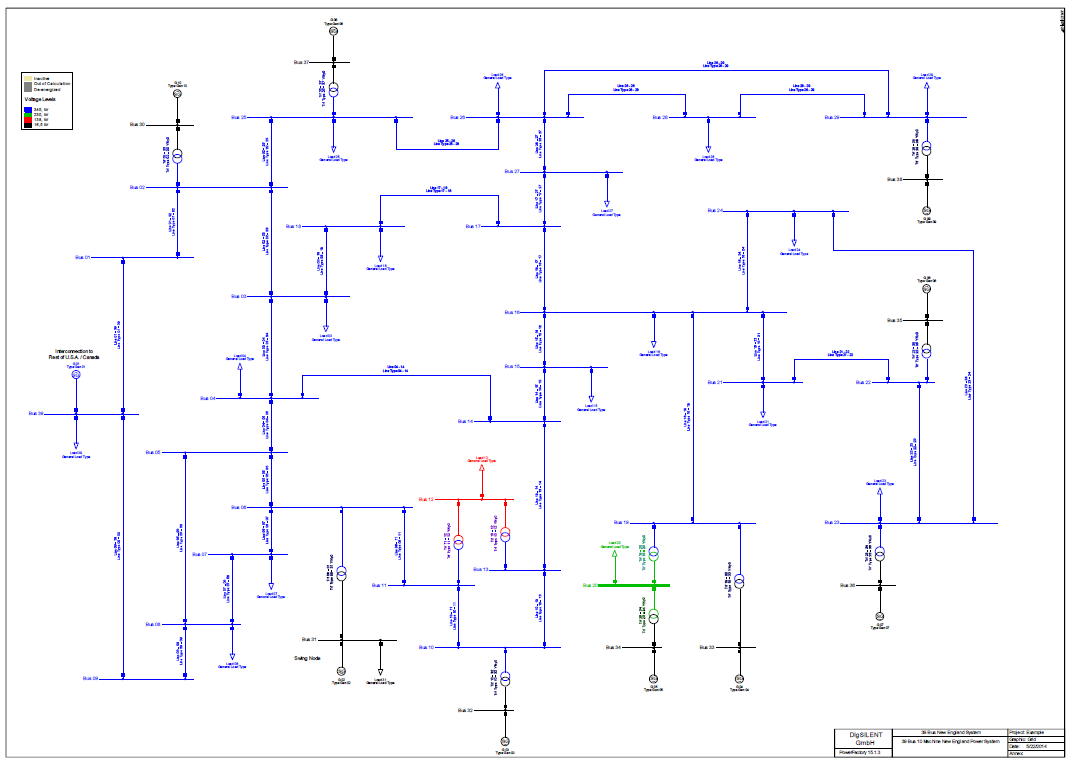

In [3]:
from IPython.display import Image #display image
print("Credit to DigSILENT PowerFactory - 39 Bus System")
Image(filename='IEEE39bus_SLD.png')

In [4]:
print("Lines Parameters")
sheet['lines']

Lines Parameters


,from_bus,to_bus,x_pu,P_max_pu,Sbase,kVbase,Zbase,Ibase,Ib,Ib_pu,Unnamed: 10
0,1,2,0.0411,6.274354,100,345,1190.25,0.167348,1.05,6.274354,1
1,1,39,0.0250,6.274354,100,345,1190.25,0.167348,1.05,6.274354,1
2,2,3,0.0151,6.274354,100,345,1190.25,0.167348,1.05,6.274354,1
3,2,25,0.0086,6.274354,100,345,1190.25,0.167348,1.05,6.274354,1
4,3,4,0.0213,6.274354,100,345,1190.25,0.167348,1.05,6.274354,1
5,3,18,0.0133,6.274354,100,345,1190.25,0.167348,1.05,6.274354,1
6,4,5,0.0128,6.274354,100,345,1190.25,0.167348,1.05,6.274354,1
7,4,14,0.0129,6.274354,100,345,1190.25,0.167348,1.05,6.274354,1
8,5,6,0.0026,6.274354,100,345,1190.25,0.167348,1.05,6.274354,1
9,5,8,0.0112,6.274354,100,345,1190.25,0.167348,1.05,6.274354,1


In [5]:
print("Transformers Parameters")
sheet['trafos']

Transformers Parameters


,from_bus,to_bus,x_pu,P_max_pu,shift_degree,Unnamed: 5
0,12,11,0.0435,3,0,3
1,12,13,0.0435,3,0,3
2,6,31,0.0250,7,0,7
3,10,32,0.0200,8,0,8
4,19,33,0.0142,8,0,8
5,20,34,0.0180,6,0,6
6,22,35,0.0143,8,0,8
7,23,36,0.0272,7,0,7
8,25,37,0.0232,7,0,7
9,2,30,0.0181,10,0,10


In [6]:
print("Generation and Load Data")
sheet['bus']

Generation and Load Data


,bus,Pg,Pd,Pg_MW,Pd_MW
0,1,0.00,0.000,0,0.0
1,2,0.00,0.000,0,0.0
2,3,0.00,3.220,0,322.0
3,4,0.00,5.000,0,500.0
4,5,0.00,0.000,0,0.0
5,6,0.00,0.000,0,0.0
6,7,0.00,2.338,0,233.8
7,8,0.00,5.220,0,522.0
8,9,0.00,0.000,0,0.0
9,10,0.00,0.000,0,0.0


In [7]:
#pv profile
pv_profile = np.array([0,0,0,0,0,0,0.02,0.15,0.40,0.65,0.80,0.88,
                      0.90,0.85,0.75,0.60,0.35,0.10,0,0,0,0,0,0])

#load profile
scale = np.array([0.45, 0.42, 0.40, 0.38, 0.40, 0.45,
                     0.55, 0.70, 0.80, 0.82, 0.80, 0.78,
                     0.75, 0.72, 0.70, 0.72, 0.78, 0.90,
                     1.00, 0.95, 0.88, 0.78, 0.65, 0.52])

base_MVA = 100

max_pv = sheet['gens']['max_p_mw_pu'][0]

Inequality Constraints

In [8]:
def inequality_constraints():
    H_ineq = []
    K_ineq = []
    
    #-----------------------------------------------------------------------
    
    #inequality constraints of lines loading:
    # abs(\theta_{i}(k) - \theta_{j}(k)) / x_ij <= P_{max,i} (k)
    
    #-----------------------------------------------------------------------
    for i in range(len(sheet['lines'])):
        fr_i = sheet['lines']['from_bus'][i] #from_bus i
        to_j = sheet['lines']['to_bus'][i] #to_bus j
        x_ij = sheet['lines']['x_pu'][i] #line impedances
        Pmax_ij = sheet['lines']['P_max_pu'][i] #rated power
        
        #construct H_part * z <= K_part
        H_part = np.zeros((2*k,(n_bus+1)*k+1)) #initialize sparse matrix for H_part
        K_part = np.zeros((2*k,1)) #initialize sparse matrix for K_part
        for j in range(k):
            #forward direction of power
            H_part[j,(fr_i-1)*k+j] = 1/x_ij
            H_part[j,(to_j-1)*k+j] = -1/x_ij
            K_part[j] = Pmax_ij
        
            #reverse direction of power
            H_part[k+j,(fr_i-1)*k+j] = -1/x_ij
            H_part[k+j,(to_j-1)*k+j] = 1/x_ij
            K_part[k+j] = Pmax_ij
    
        if i == 0:
            H_ineq = H_part
            K_ineq = K_part
        else:
            H_ineq = np.vstack((H_ineq, H_part))
            K_ineq = np.vstack((K_ineq, K_part))
    
    #-----------------------------------------------------------------------
    
    #inequality constraints for transformers loading:
    # ( \theta_{i}(k) - \theta_{j}(k) ) / x_ij <= P_{max,i} (k) - phi_{ij} - forward direction
    # ( - \theta_{i}(k) + \theta_{j}(k) ) / x_ij <= P_{max,i} (k) + phi_{ij} - reverse direction
    
    #-----------------------------------------------------------------------
    for i in range(len(sheet['trafos'])):
        fr_i = sheet['trafos']['from_bus'][i] #from_bus i
        to_j = sheet['trafos']['to_bus'][i] #to_bus j
        x_ij = sheet['trafos']['x_pu'][i] #trafo impedance
        phi_ij = np.deg2rad(sheet['trafos']['shift_degree'][i]) #phase shift in radian
        Pmax_i = sheet['trafos']['P_max_pu'][i] #rated power of transformer
    
        #construct H_part * z <= K_part
        H_part = np.zeros((2*k,(n_bus+1)*k+1)) #initialize sparse matrix for H_part
        K_part = np.zeros((2*k,1)) #initialize sparse matrix for K_part
    
        for j in range(k):
            #forward direction
            H_part[j,(fr_i-1)*k+j] = 1/x_ij
            H_part[j,(to_j-1)*k+j] = -1/x_ij
            K_part[j] = Pmax_i - phi_ij/x_ij
    
            #reverse direction
            H_part[k+j,(fr_i-1)*k+j] = -1/x_ij
            H_part[k+j,(to_j-1)*k+j] = 1/x_ij
            K_part[k+j] = Pmax_i + phi_ij/x_ij
        
        #add new sparse inequalities of transformers to existing H_ineq
        H_ineq = np.vstack((H_ineq, H_part))
        K_ineq = np.vstack((K_ineq, K_part))
    
    
    #-----------------------------------------------------------------------
    
    #inequality constraints for generator's loading:
    #P_{grid,min} <= P_{grid}(k) <= P_{grid,max}
    
    #-----------------------------------------------------------------------
    
    #construct H_part * z <= K_part
    H_part = np.zeros((2*k,(n_bus+1)*k+1)) #initialize sparse matrix for H_part
    K_part = np.zeros((2*k,1)) #initialize sparse matrix for K_part
    
    #fill H_part and K_part elements
    for j in range(k):
        #upper limit of generation
        H_part[j,n_bus*k+j] = 1
        K_part[j] = sheet['gens']['max_p_mw_pu'][0]
    
        #lower limit of generation
        H_part[k+j,n_bus*k+j] = -1
        K_part[k+j] = -sheet['gens']['min_p_mw_pu'][0]
    
    H_ineq = np.vstack((H_ineq, H_part))
    K_ineq = np.vstack((K_ineq, K_part))

    #-----------------------------------------------------------------------
    
    #inequality constraints for PV capacity:
    # 0 <= S_PV <= Grid_maximum_power
    
    #-----------------------------------------------------------------------
    H_part = np.zeros((2,(n_bus+1)*k+1)) #initialize H_part
    K_part = np.zeros((2,1))
    K_part[0,0] = sheet['gens']['max_p_mw_pu'][0]

    H_part[0,(n_bus+1)*k] = 1
    H_part[1,(n_bus+1)*k] = -1

    H_ineq = np.vstack((H_ineq, H_part))
    K_ineq = np.vstack((K_ineq, K_part))

    #-----------------------------------------------------------------------
    
    #inequality constraints for bus voltage angle:
    # -pi <= \theta_i(k) <= pi
    
    #-----------------------------------------------------------------------
    for i in range(n_bus):
        H_part = np.zeros((2*k,(n_bus+1)*k+1)) #initialize H_part
        K_part = np.zeros((2*k,1)) #initialize K_part

        for t in range(k):
            # \theta_i(k) <= pi
            H_part[t,i*k+t] = 1
            K_part[t] = math.pi

            # -\theta_i(k) <= pi
            H_part[t+k,i*k+t] = -1
            K_part[t+k] = math.pi

        H_ineq = np.vstack((H_ineq, H_part))
        K_ineq = np.vstack((K_ineq, K_part))
    
    return (H_ineq, K_ineq)

In [9]:
H_ineq, K_ineq = inequality_constraints()
print(H_ineq.shape)
print(K_ineq.shape)

(4130, 961)
(4130, 1)


In [10]:
# JUST FOR CHECKING THE MATRICES

# Define the path to the Excel file
#excel_file_path = 'dataH_ineq.xlsx'

# Convert the NumPy array to a Pandas DataFrame
#df = pd.DataFrame(H_ineq)

# Write the DataFrame to an Excel file
#df.to_excel(excel_file_path, index=False)

In [11]:
# JUST FOR CHECKING THE MATRICES

# Define the path to the Excel file
#excel_file_path = 'dataK_ineq.xlsx'

# Convert the NumPy array to a Pandas DataFrame
#df = pd.DataFrame(K_ineq)

# Write the DataFrame to an Excel file
#df.to_excel(excel_file_path, index=False)

In [12]:
# Define the single Excel file path
excel_file_path = 'inequalities.xlsx'

# Use ExcelWriter to handle multiple sheets
with pd.ExcelWriter(excel_file_path) as writer:
    # Convert and write H_ineq
    df_H = pd.DataFrame(H_ineq)
    df_H.to_excel(writer, sheet_name='H_ineq', index=False)
    
    # Convert and write K_ineq
    df_K = pd.DataFrame(K_ineq)
    df_K.to_excel(writer, sheet_name='K_ineq', index=False)

Equality Constraints

In [13]:
def equality_constraints(new_gen_bus):
    H_eq = []
    K_eq = []
    
    #-----------------------------------------------------------------------
    
    #equality constraints for slack bus
    # \theta_1 (k) = 0
    
    #-----------------------------------------------------------------------
    H_part = np.zeros((k, (n_bus+1)*k+1)) #initialize sparse matrix for H_part
    K_part = np.zeros((k,1)) #initialize sparse matrix for K_part
    slack = sheet['gens']['bus'][0]
    for t in range(k):
        H_part[t,(slack-1)*k+t] = 1
    
    H_eq = H_part
    K_eq = K_part
    
    #equality constraints for branch power flows
    for i in range(len(sheet['bus'])):
        H_part = np.zeros((k, (n_bus+1)*k+1)) #initialize sparse matrix for H_part
        K_part = np.zeros((k,1)) #initialize sparse matrix for K_part
        H_temp = 0
    
        #fill K_part elements
        for t in range(k):
            K_part[t,0] = sheet['bus']['Pg'][i]*scale[t] - sheet['bus']['Pd'][i]*scale[t]
    
        #search common branch in lines sheet
        for j in range(len(sheet['lines'])):
            x_ij = sheet['lines']['x_pu'][j]
            if (sheet['lines']['from_bus'][j]-1) == i:
                to_j = sheet['lines']['to_bus'][j]
                H_temp = H_temp + 1 / x_ij
                for t in range(k):
                    H_part[t,(to_j-1)*k+t] = -1/x_ij
            if (sheet['lines']['to_bus'][j]-1) == i:
                fr_i = sheet['lines']['from_bus'][j]
                H_temp = H_temp + 1 / x_ij
                for t in range(k):
                    H_part[t,(fr_i-1)*k+t] = -1/x_ij
    
        #search common branch in trafos sheet
        for j in range(len(sheet['trafos'])):
            x_ij = sheet['trafos']['x_pu'][j]
            phi_ij = np.deg2rad(sheet['trafos']['shift_degree'][j])
            to_j = sheet['trafos']['to_bus'][j]
            fr_i = sheet['trafos']['from_bus'][j]
            
            if (fr_i-1) == i:    
                H_temp = H_temp + 1 / x_ij
                for t in range(k):
                    H_part[t,(to_j-1)*k+t] = -1 / x_ij
                    K_part[t,0] = K_part[t,0] - phi_ij / x_ij
            if (to_j-1) == i:
                H_temp = H_temp + 1 / x_ij
                for t in range(k):
                    H_part[t,(fr_i-1)*k+t] = -1 / x_ij
                    K_part[t,0] = K_part[t,0] + phi_ij / x_ij
        for t in range(k):
            H_part[t,i*k+t] = H_temp
    
        #search external grid in the same bus
        if (sheet['gens']['bus'][0]-1) == i:
            for t in range(k):
                H_part[t,(n_bus)*k+t] = -1
        
        #search PV in the same bus
        if (new_gen_bus) == i:
            for t in range(k):
                H_part[t,(n_bus+1)*k] = -pv_profile[t] #pv_profile[t]
    
        H_eq = np.vstack((H_eq, H_part))
        K_eq = np.vstack((K_eq, K_part))
    
    return(H_eq, K_eq)

In [14]:
#printing equality constraints for specific bus injection
H_eq, K_eq = equality_constraints(5)
print(H_eq.shape)
print(K_eq.shape)

(960, 961)
(960, 1)


In [15]:
# JUST FOR CHECKING WHETHER THE MATRIX IS CORRECT

# Define the path to the Excel file
#excel_file_path = 'dataH_eq.xlsx'

# Convert the NumPy array to a Pandas DataFrame
#df = pd.DataFrame(H_eq)

# Write the DataFrame to an Excel file
#df.to_excel(excel_file_path, index=False)

In [16]:
# JUST FOR CHECKING WHETHER THE MATRIX IS CORRECT

# Define the path to the Excel file
#excel_file_path = 'dataK_eq.xlsx'

# Convert the NumPy array to a Pandas DataFrame
#df = pd.DataFrame(K_eq)

# Write the DataFrame to an Excel file
#df.to_excel(excel_file_path, index=False)

In [17]:
# Define the single Excel file path
excel_file_path = 'equalities.xlsx'

# Use ExcelWriter to handle multiple sheets
with pd.ExcelWriter(excel_file_path) as writer:
    # Convert and write H_ineq
    df_H = pd.DataFrame(H_eq)
    df_H.to_excel(writer, sheet_name='H_eq', index=False)
    
    # Convert and write K_ineq
    df_K = pd.DataFrame(K_eq)
    df_K.to_excel(writer, sheet_name='K_eq', index=False)

LP Formulation

In [18]:
#defining objective function
c = np.zeros((1,(n_bus+1)*k+1))
c[0,(n_bus+1)*k] = -1
#for ts in range(k):
#    c[0,(n_bus)*k+ts] = -1 #maximize S^{PV}

#initializing variables to store optimization results
theta_k = []
Pgrid_k = []
PV_cap = []

#extracting inequality constraints
H_ineq, K_ineq = inequality_constraints()

bounds = [(None, None)] * (n_bus * k) + [(0, None)] * k + [(0, None)]

#iterating for solving optimization in each bus
for i in range(n_bus):

    #extracting equality constraints
    H_eq, K_eq = equality_constraints(i)

    #solve LP
    res = linprog(c, A_ub=H_ineq, b_ub=K_ineq, A_eq = H_eq, b_eq=K_eq, bounds=bounds)
    print("Optimization for new PV at bus " + str(i+1) + ": " + res.message)

    #storing optimization results
    if i == 0:
        theta_k = res.x[0:(n_bus)*k]*180/math.pi
        Pgrid_k = res.x[(n_bus)*k:(n_bus+1)*k] * base_MVA
        PV_cap = res.x[(n_bus+1)*k]
    else:
        theta_k = np.vstack((theta_k, res.x[0:(n_bus)*k]*180/math.pi))
        Pgrid_k = np.vstack((Pgrid_k, res.x[(n_bus)*k:(n_bus+1)*k] * base_MVA))
        PV_cap = np.hstack((PV_cap, res.x[(n_bus+1)*k]))

Optimization for new PV at bus 1: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimization for new PV at bus 2: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimization for new PV at bus 3: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimization for new PV at bus 4: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimization for new PV at bus 5: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimization for new PV at bus 6: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimization for new PV at bus 7: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimization for new PV at bus 8: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimization for new PV at bus 9: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimization for new PV at bus 10: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimization for ne

In [19]:
#printing bus voltage angle

#for i in range(n_bus):
#    print("Bus voltage angle for PV injection at bus " + str(i+1))
#    for n in range(n_bus):
#        print("Bus " + str(n+1) + " voltage angle")
#        print(theta_k[i][(n)*k:(n+1)*k])
#    print("---------------------------------------------------------------------")

In [20]:
#printing hosting capacity of PV in each bus

for i in range(n_bus):
    print("Max PV Capacity [MWp] at Bus " + str(i+1) + " injection = " + str(round(PV_cap[i]*base_MVA,2)) + " MWp")

Max PV Capacity [MWp] at Bus 1 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 2 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 3 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 4 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 5 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 6 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 7 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 8 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 9 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 10 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 11 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 12 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 13 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 14 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 15 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 16 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 17 injection = 397.58 MWp
Max PV Capacity [MWp] at Bus 18 injection = 397.58 MWp
Max PV Capacity [MW

Plotting

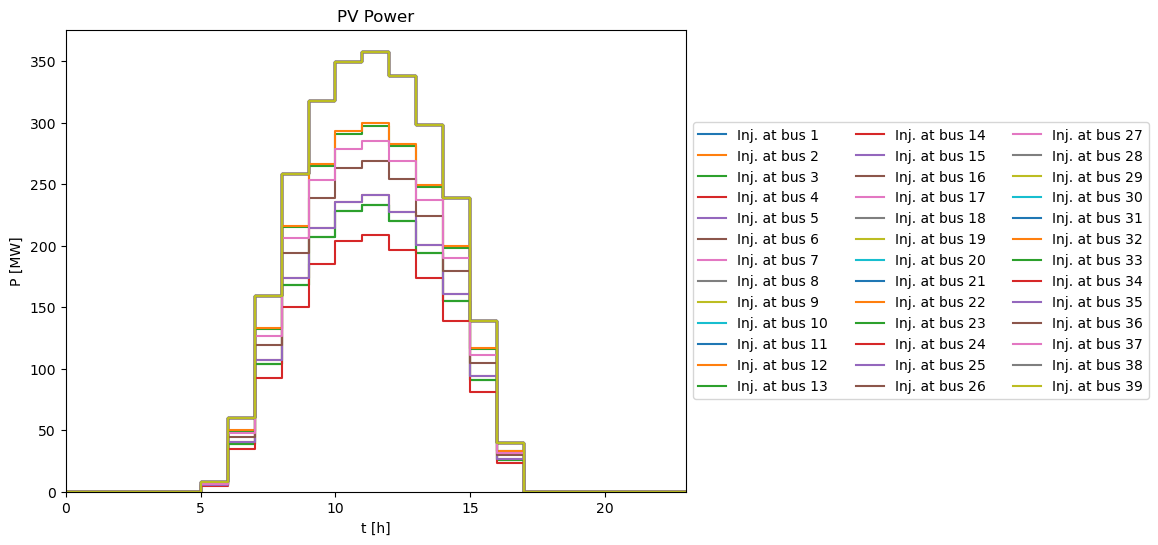

In [26]:
#-----------------------------------------------------------------------
    
#Plotting PV power for each bus injection of PV
    
#-----------------------------------------------------------------------

#initialize for generating set of legends
lgnd = []
t = np.array([0,1,2,3,4,5,
             6,7,8,9,10,11,
             12,13,14,15,16,17,
             18,19,20,21,22,23])

plt.figure(figsize=(8,6))
for bus in range(n_bus):
    #plot step graph
    plt.step(t,PV_cap[bus]*pv_profile*base_MVA)

    #generate and concatenate legends
    if len(lgnd) == 0:
        lgnd = ["Inj. at bus " + str(bus+1)]
    else:
        lgnd = np.hstack((lgnd, ["Inj. at bus " + str(bus+1)]))

#plot settings
plt.xlabel("t [h]")
plt.ylabel("P [MW]")
plt.title("PV Power")
plt.legend(lgnd,ncol=3,loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylim(bottom=0)
plt.xlim(0,23)
plt.show()

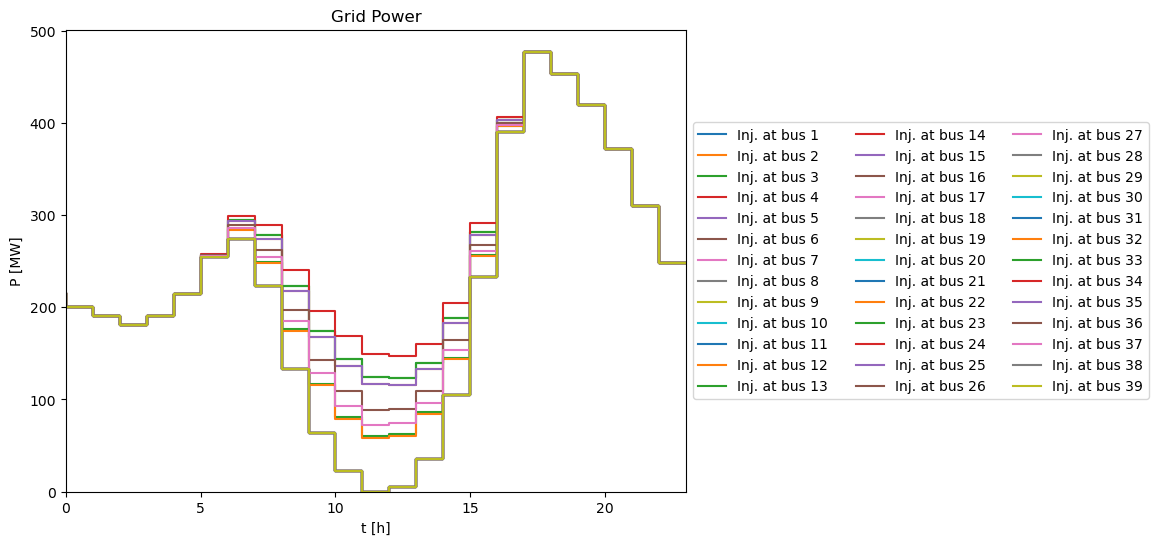

In [27]:
#-----------------------------------------------------------------------
    
#Plotting Grid power for each bus injection of PV
    
#-----------------------------------------------------------------------

#initialize for generating set of legends
lgnd = []
t = np.array([0,1,2,3,4,5,
             6,7,8,9,10,11,
             12,13,14,15,16,17,
             18,19,20,21,22,23])

plt.figure(figsize=(8,6))
for bus in range(n_bus):
    #plot step graph
    plt.step(t,Pgrid_k[bus])

    #generate and concatenate legends
    if len(lgnd) == 0:
        lgnd = ["Inj. at bus " + str(bus+1)]
    else:
        lgnd = np.hstack((lgnd, ["Inj. at bus " + str(bus+1)]))

#plot settings
plt.xlabel("t [h]")
plt.ylabel("P [MW]")
plt.title("Grid Power")
plt.legend(lgnd,ncol=3,loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylim(bottom=0)
plt.xlim(0,23)
plt.show()

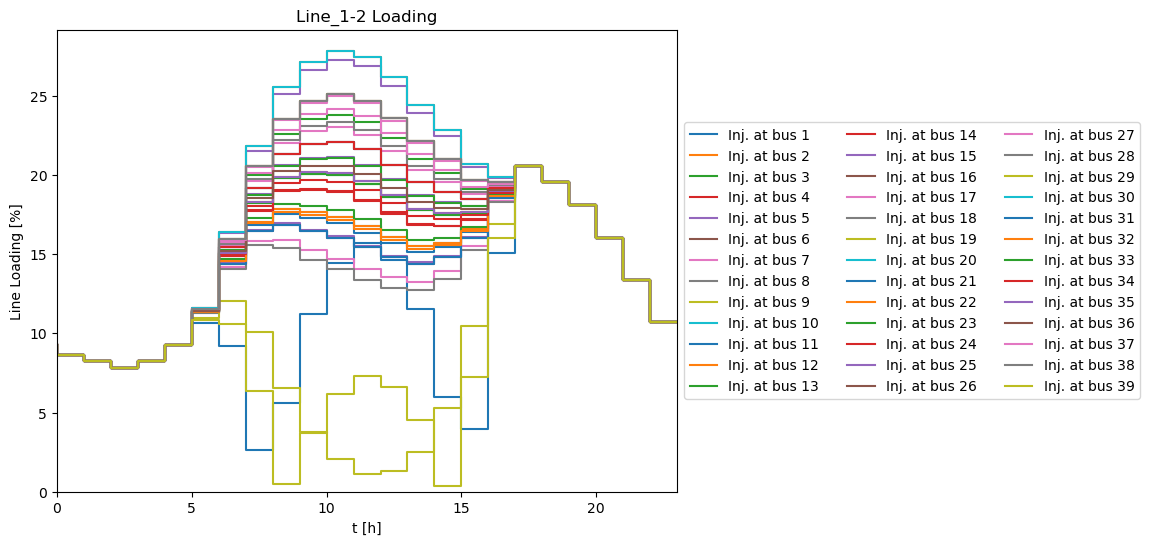

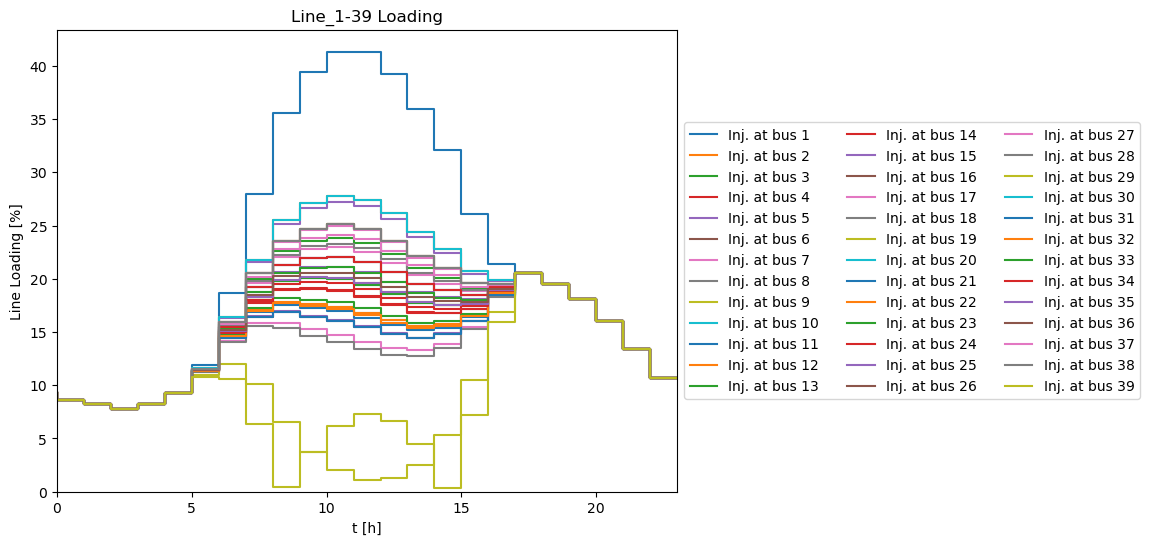

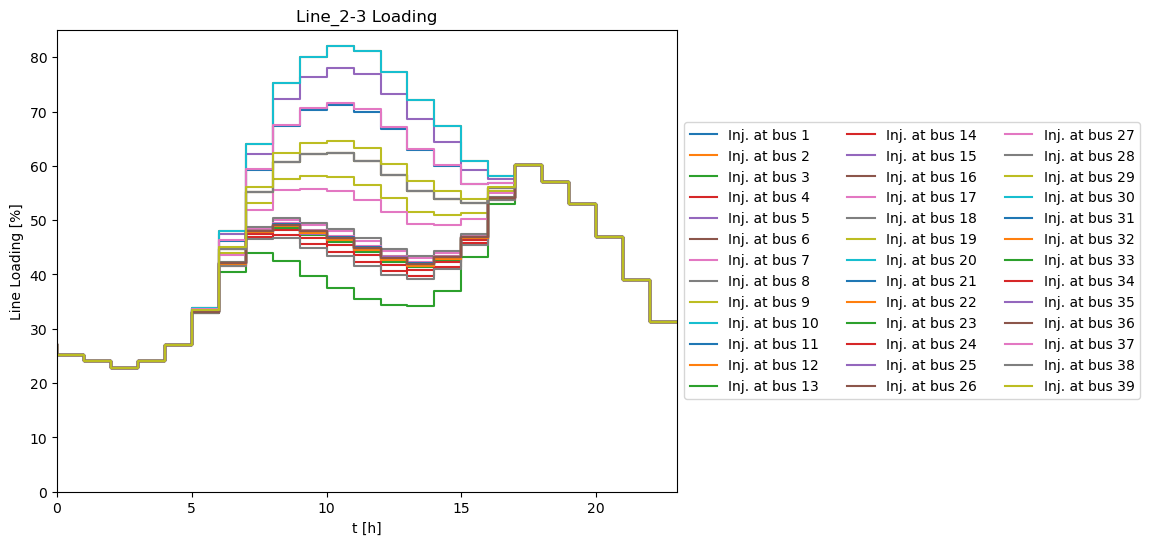

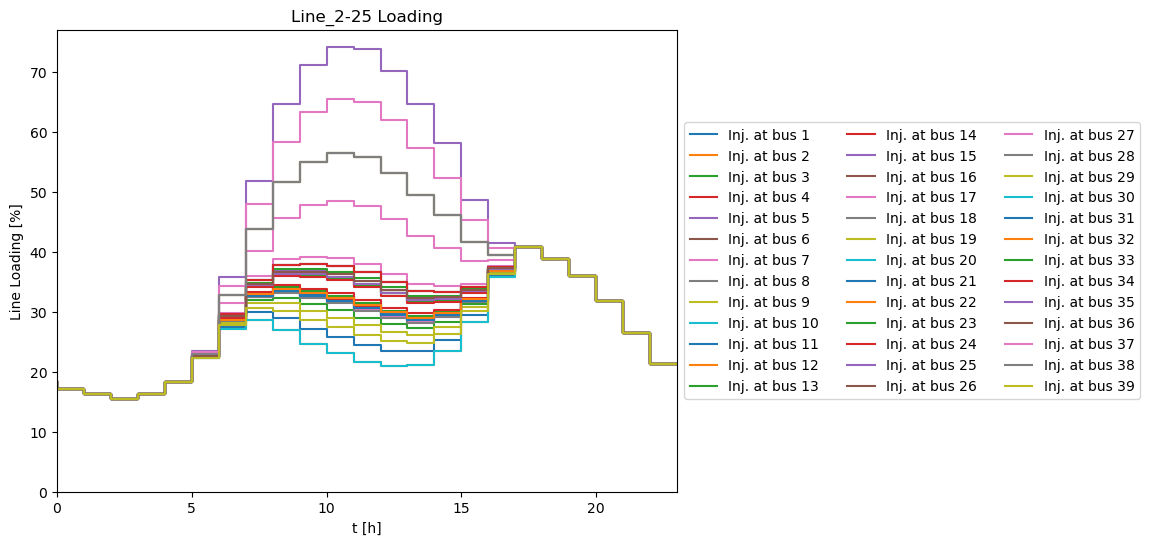

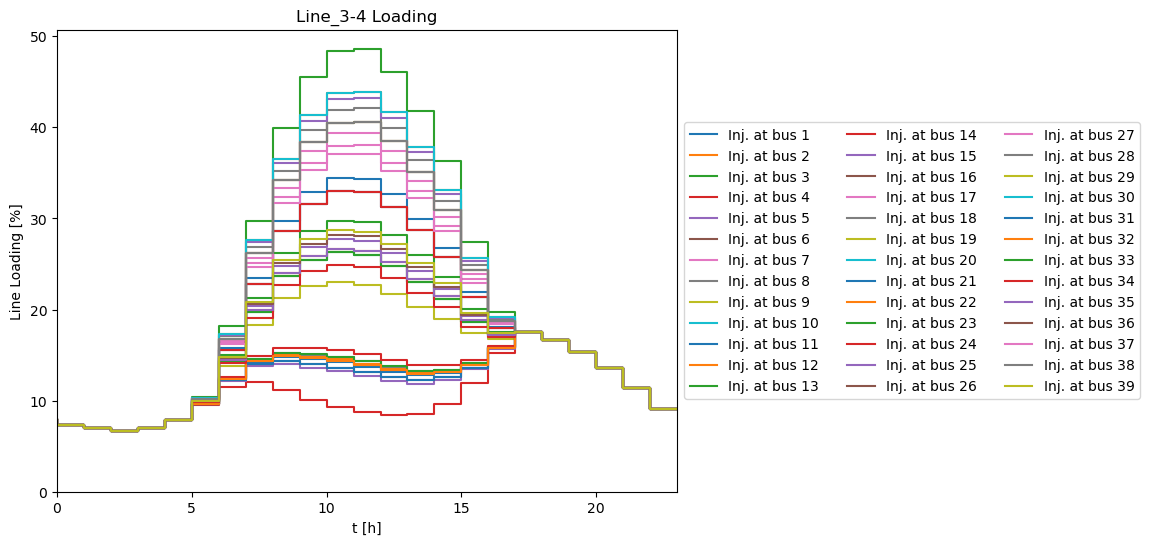

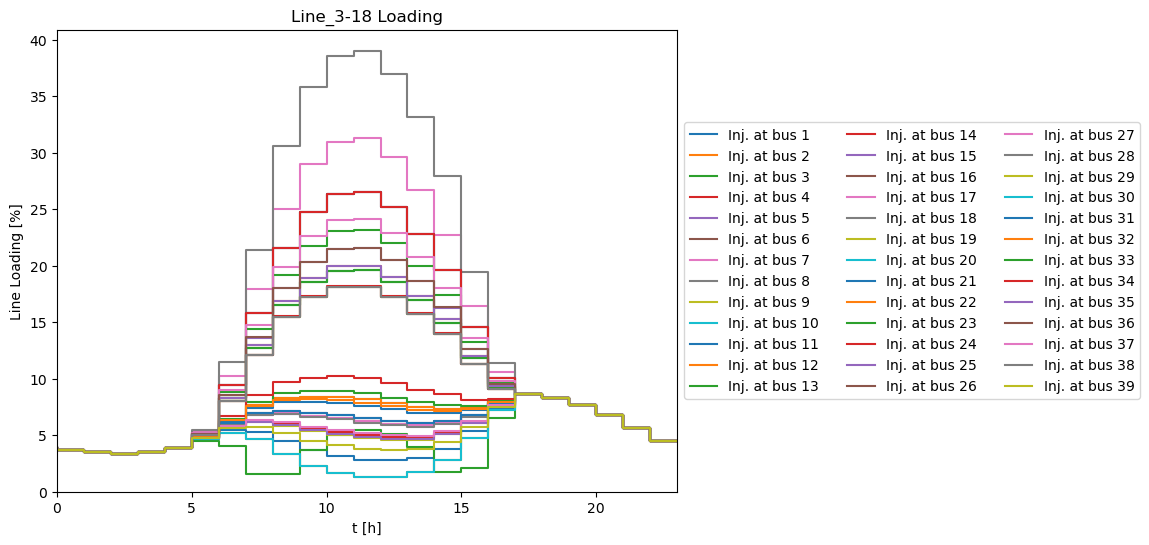

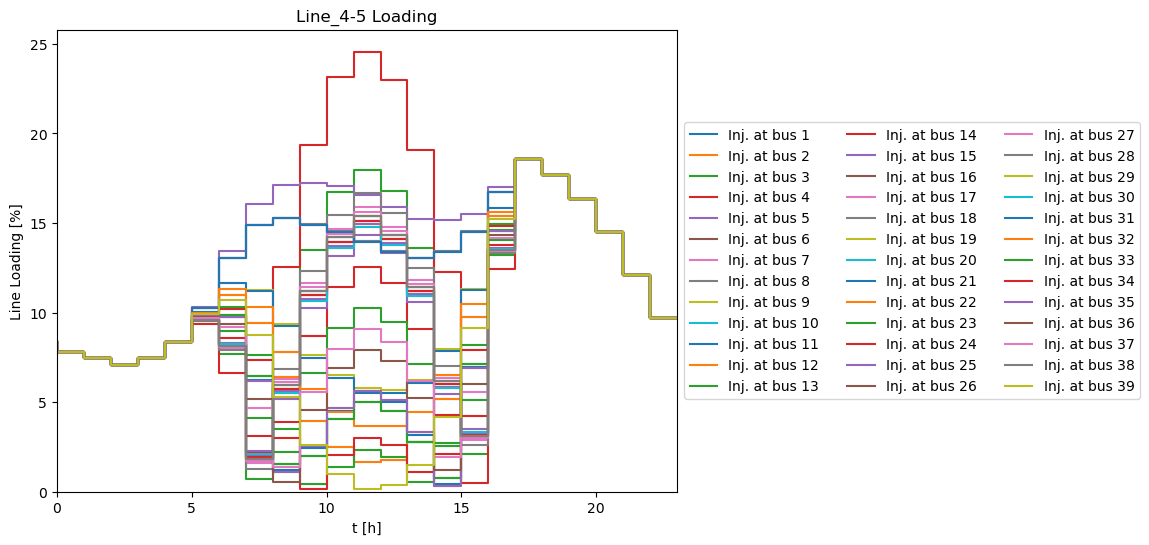

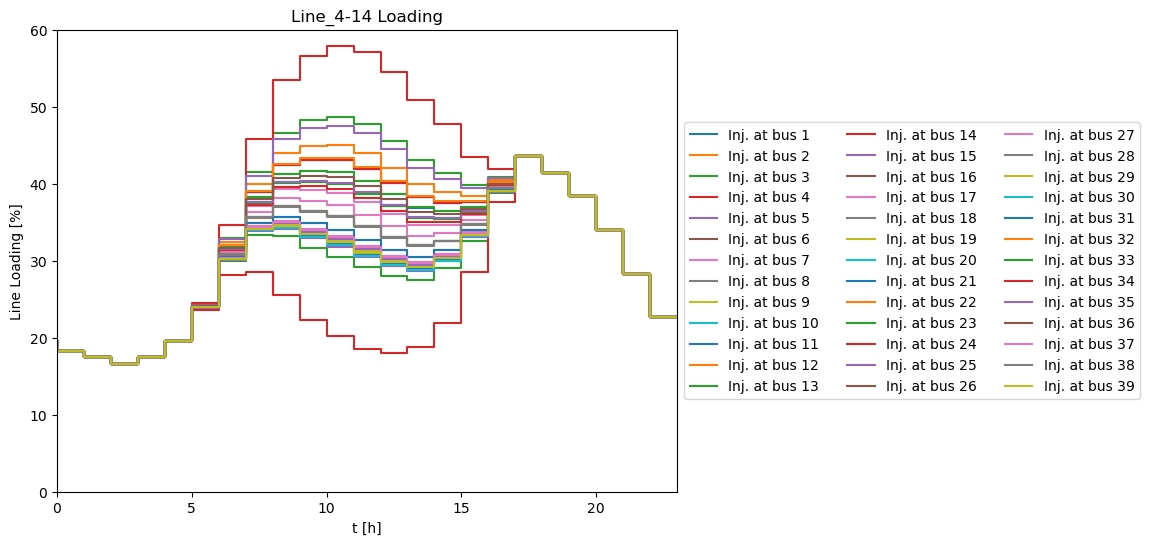

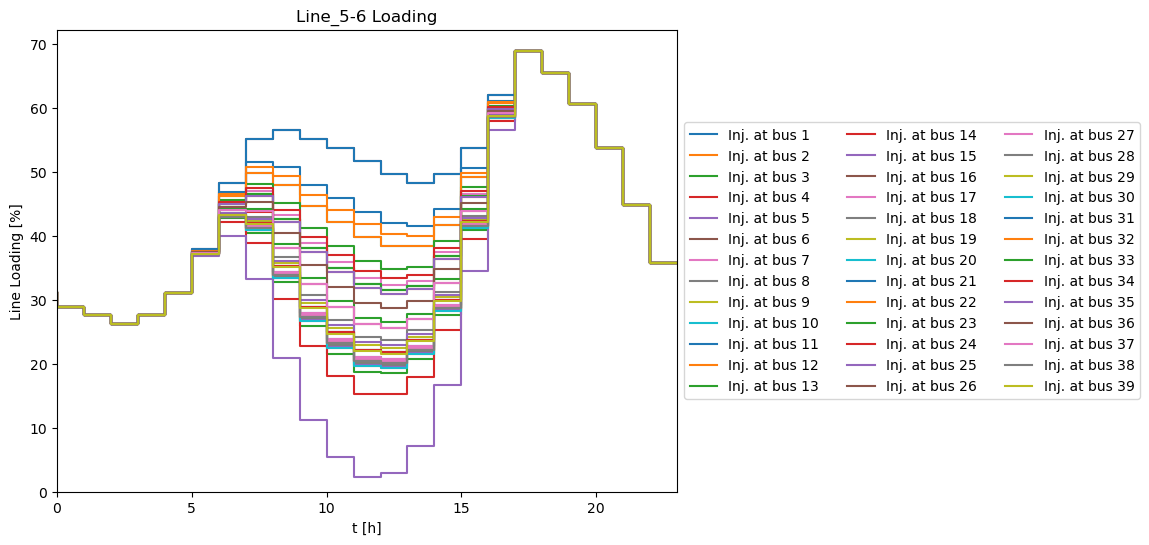

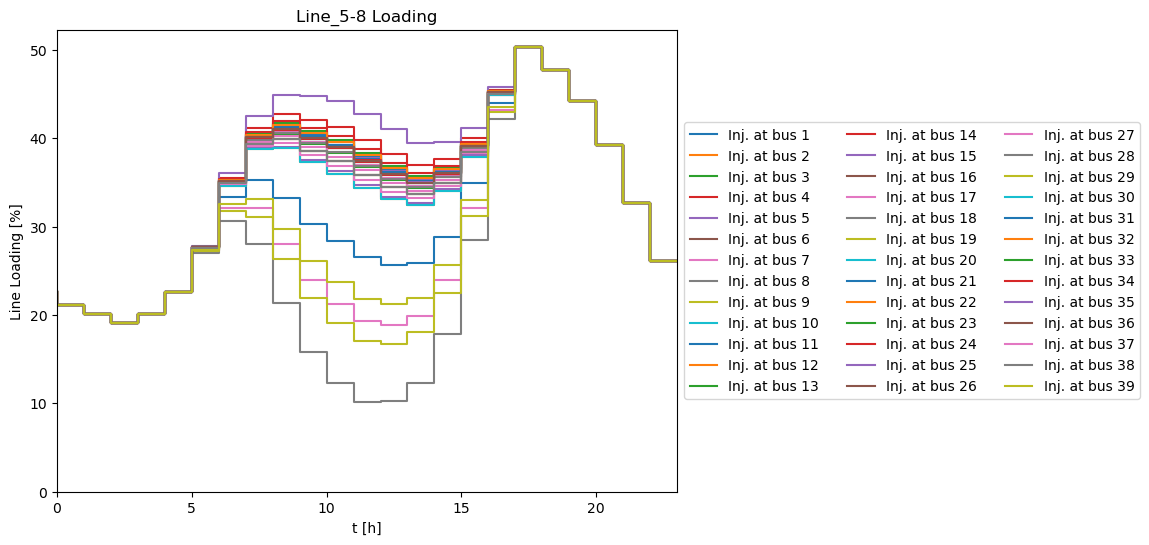

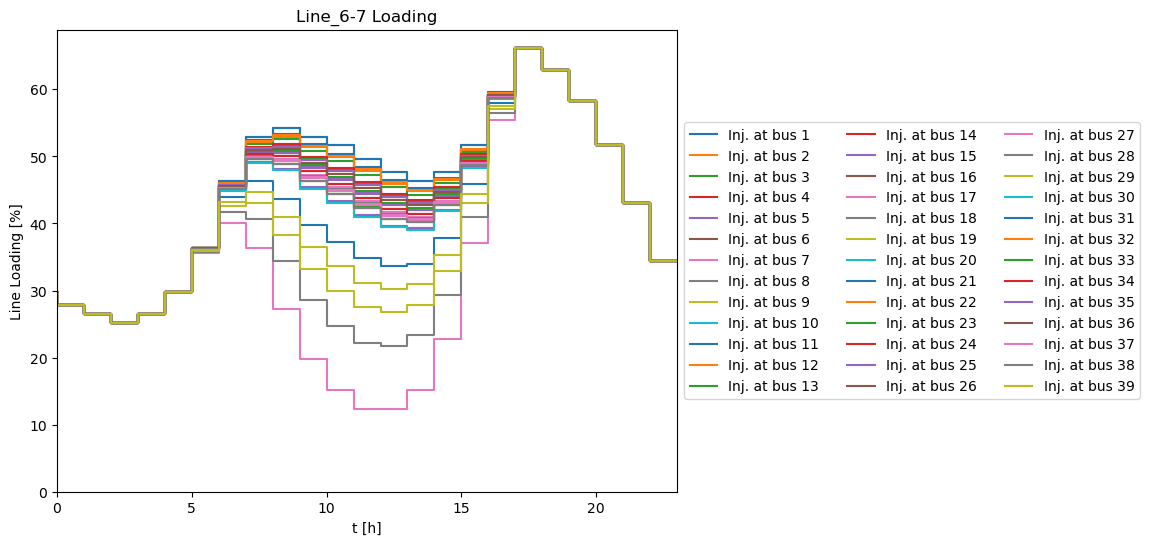

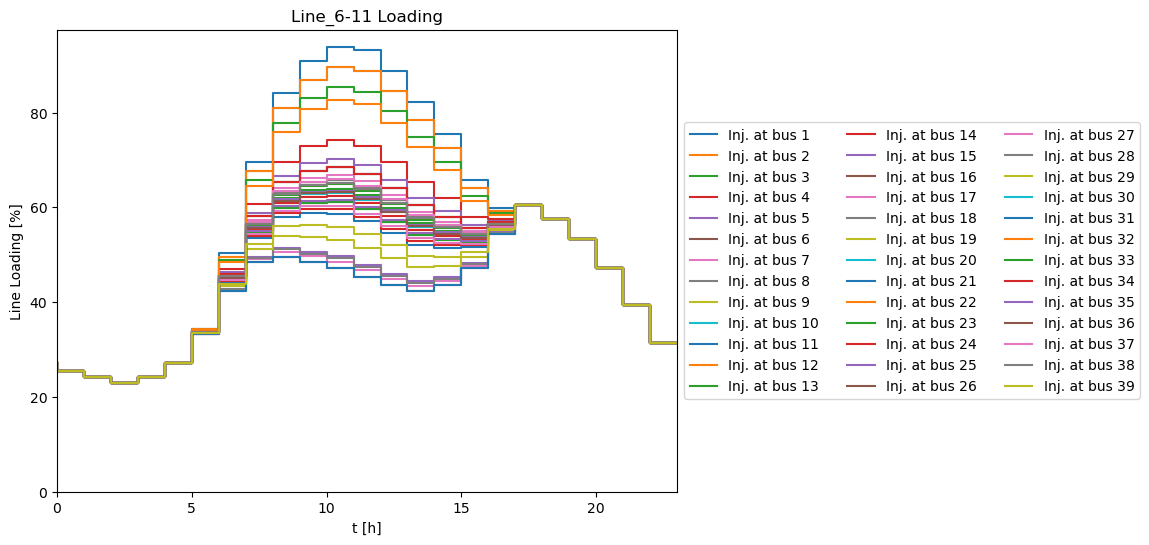

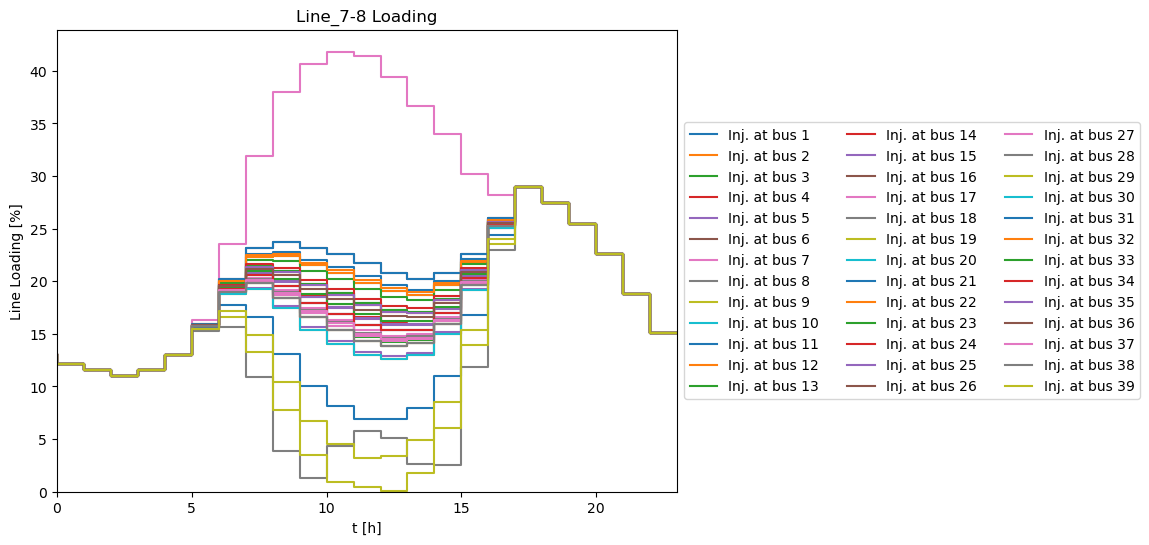

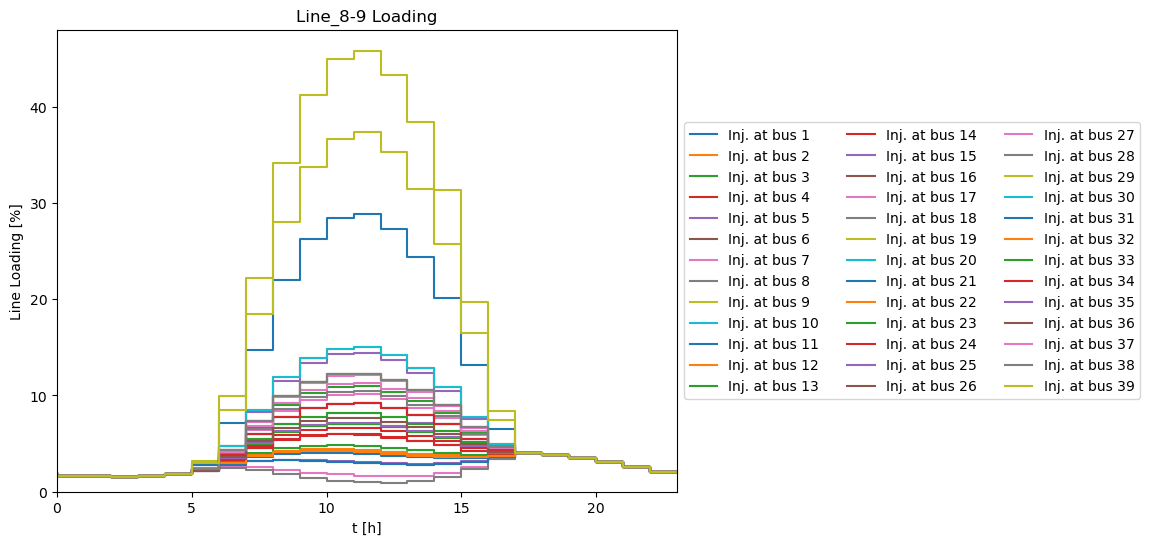

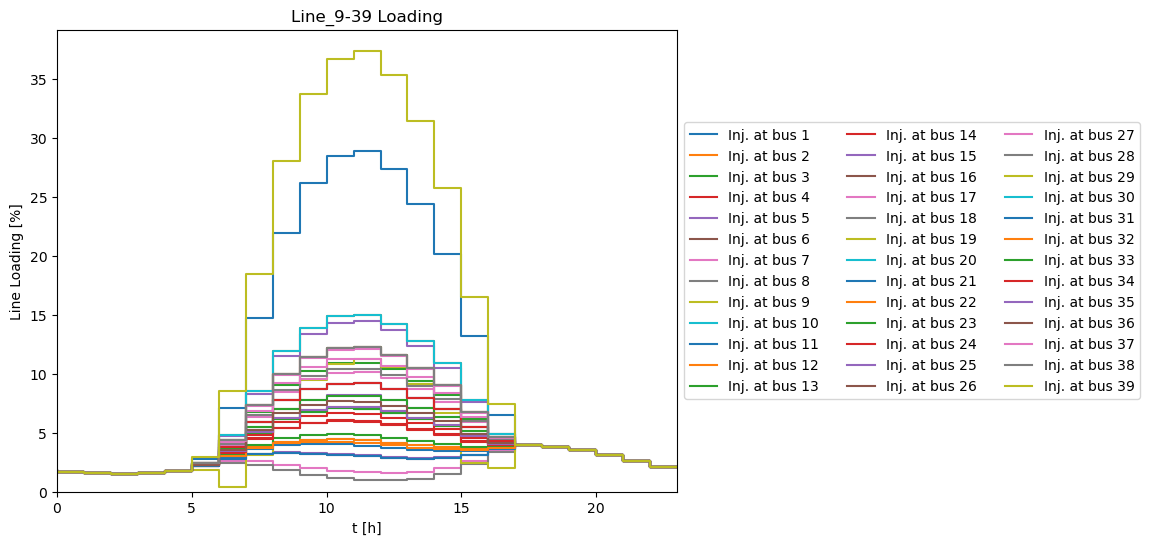

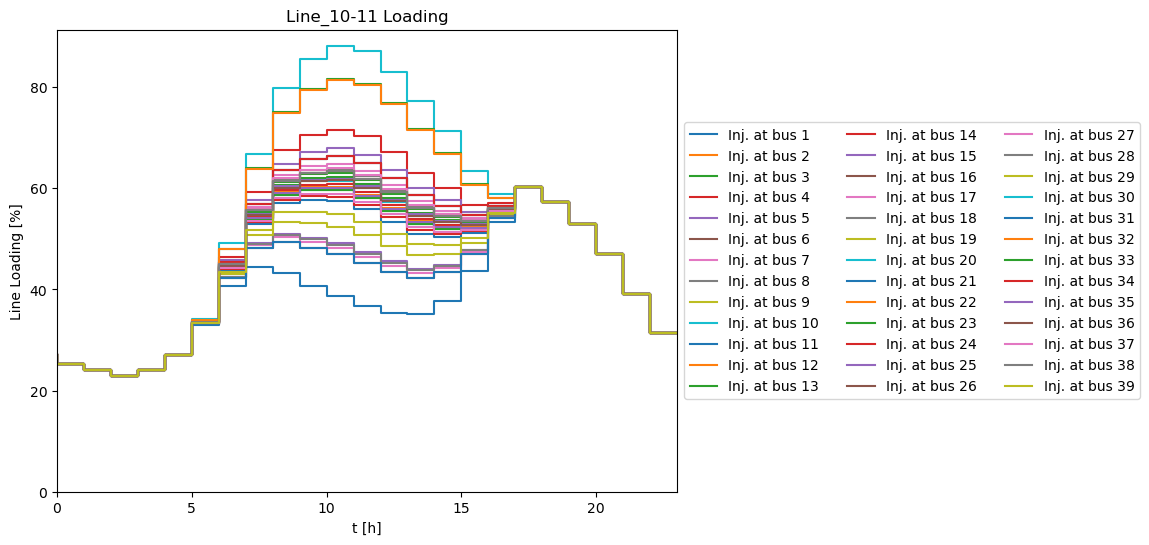

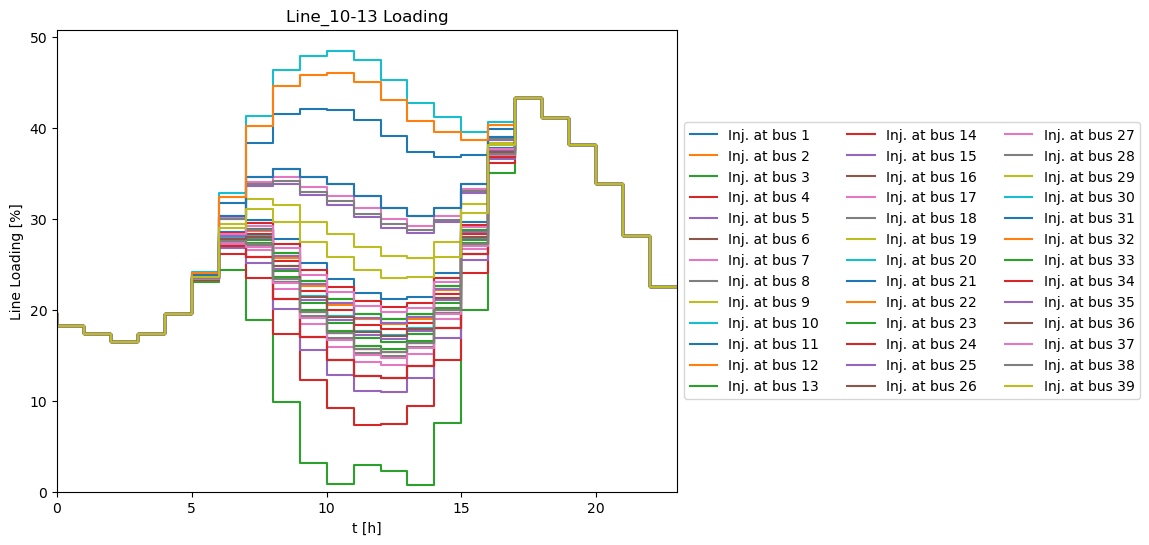

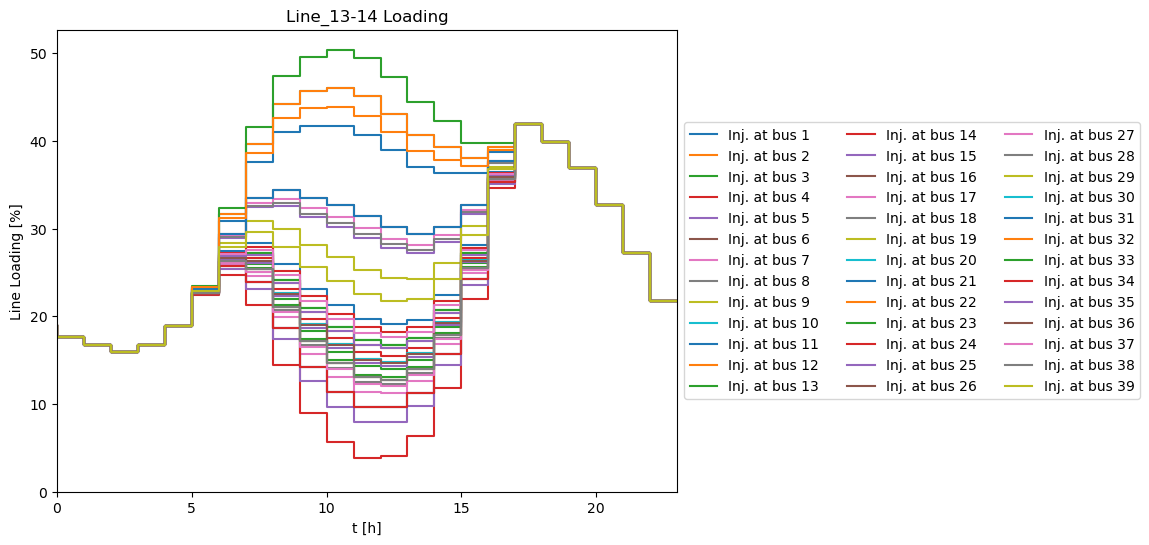

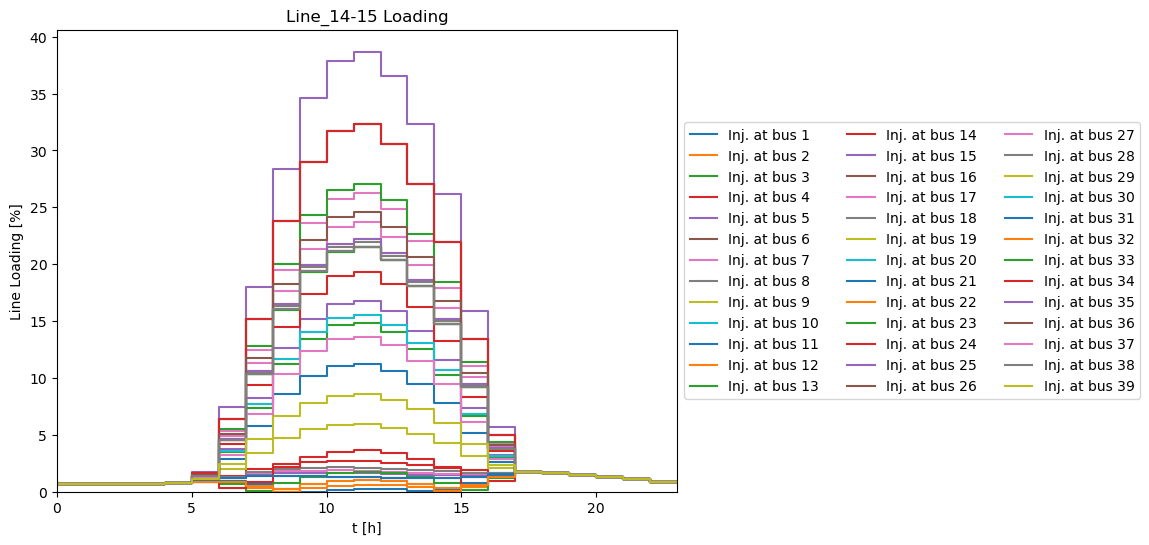

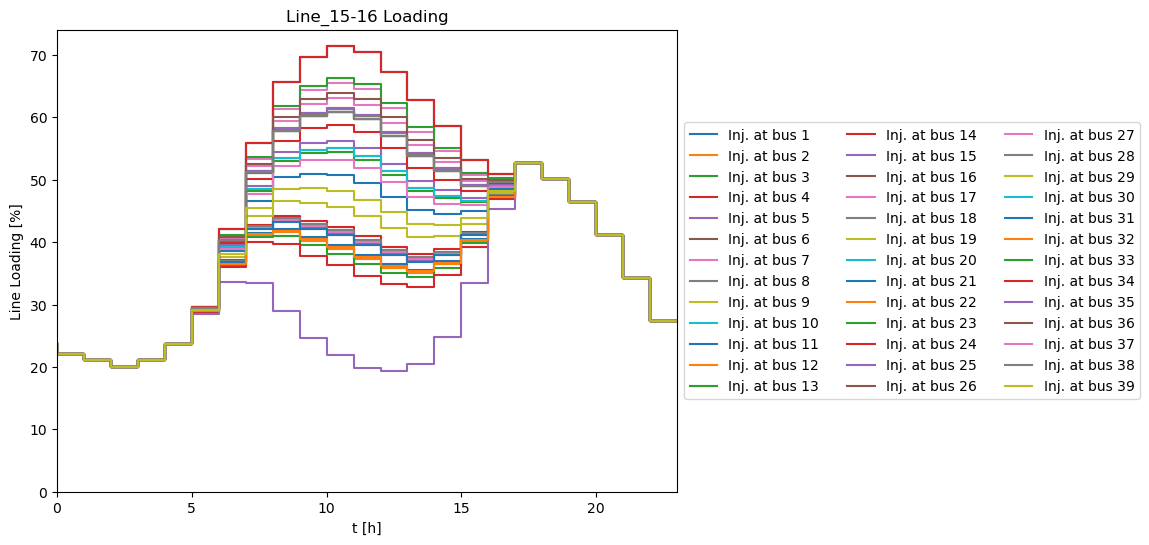

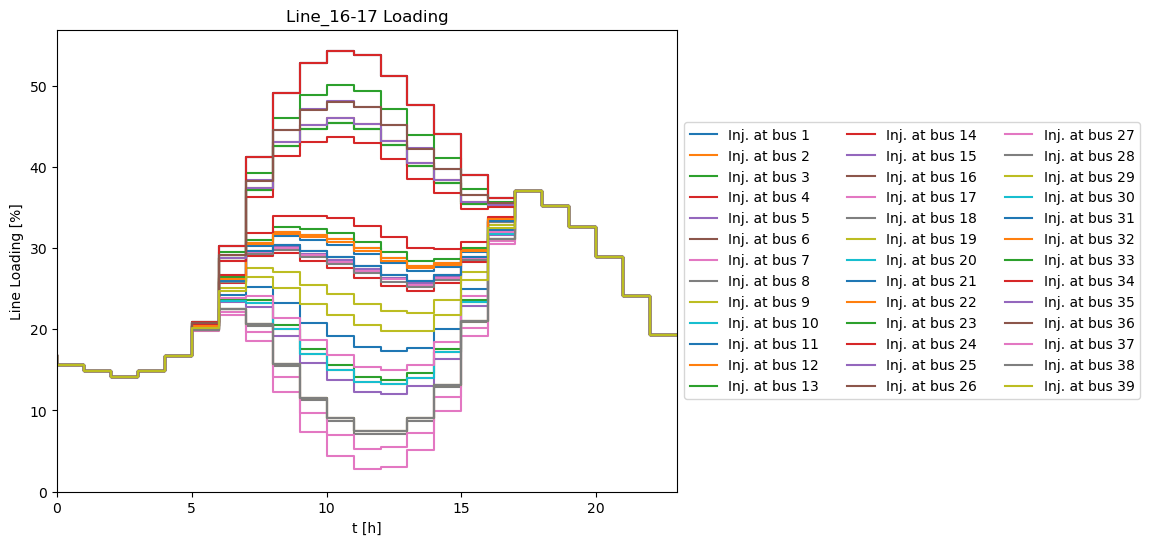

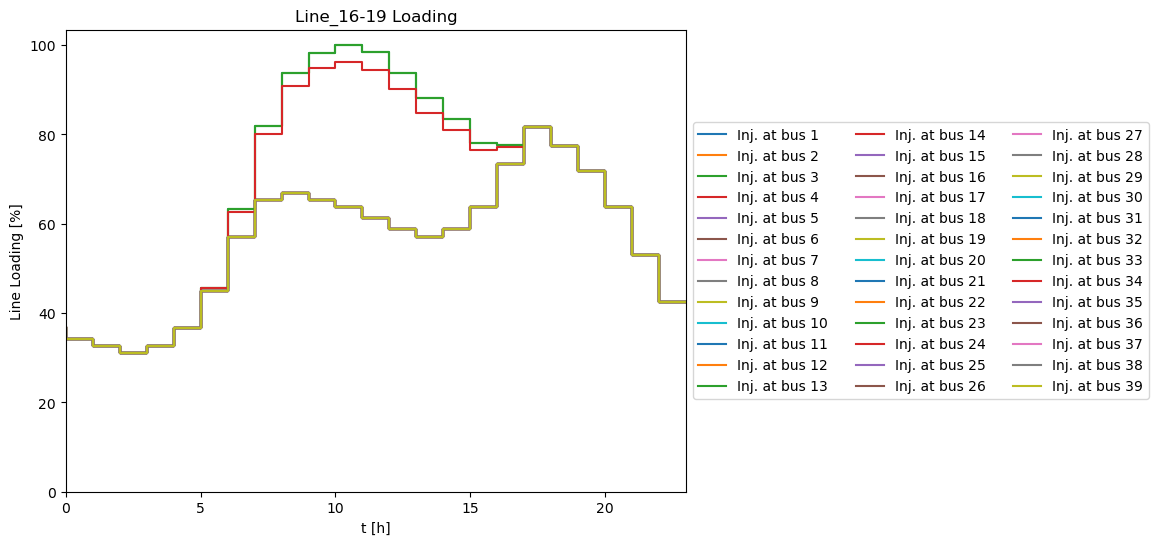

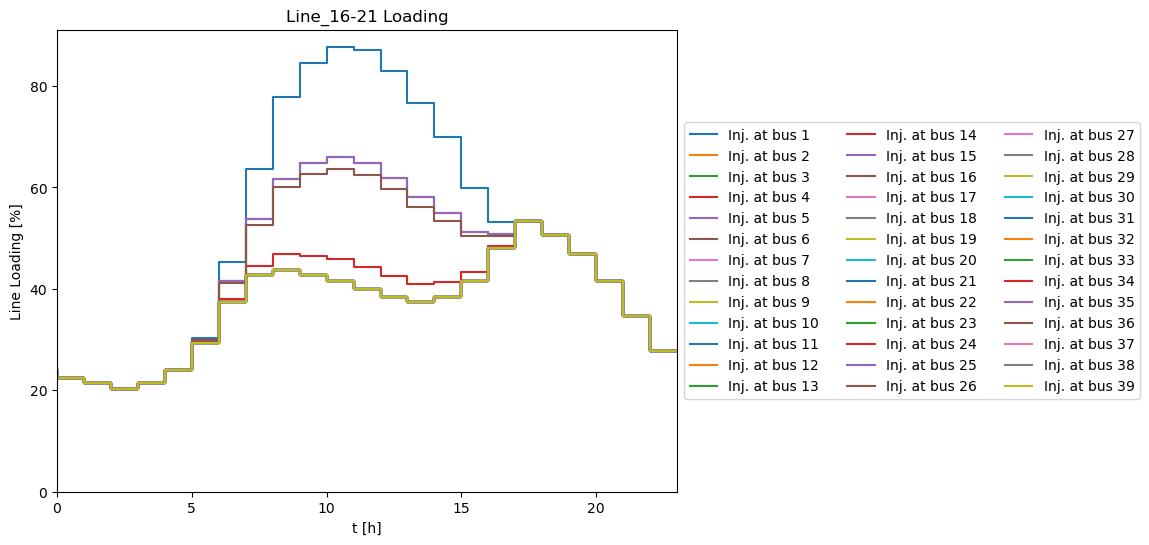

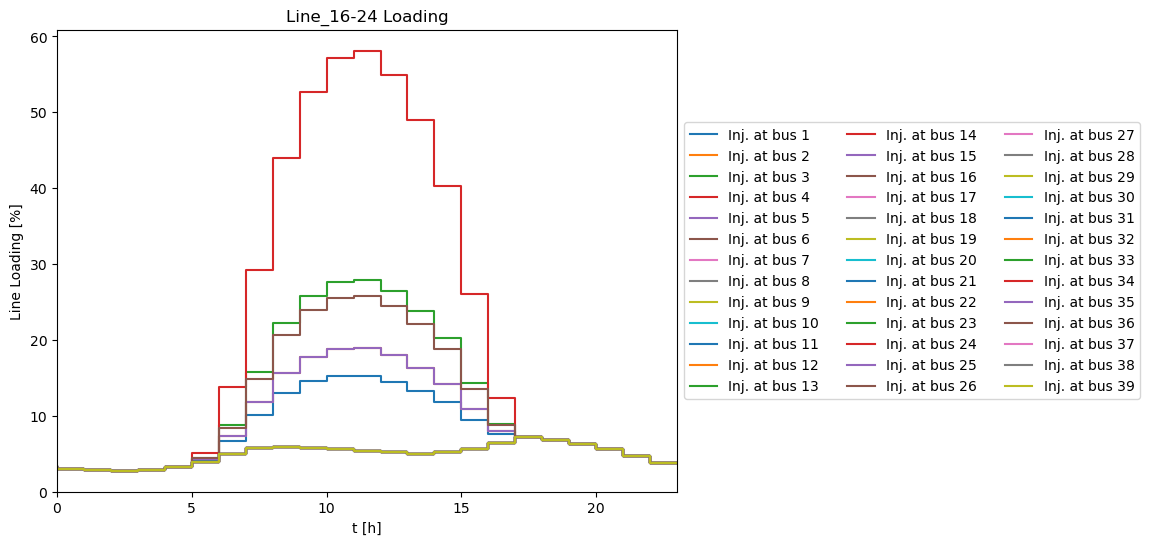

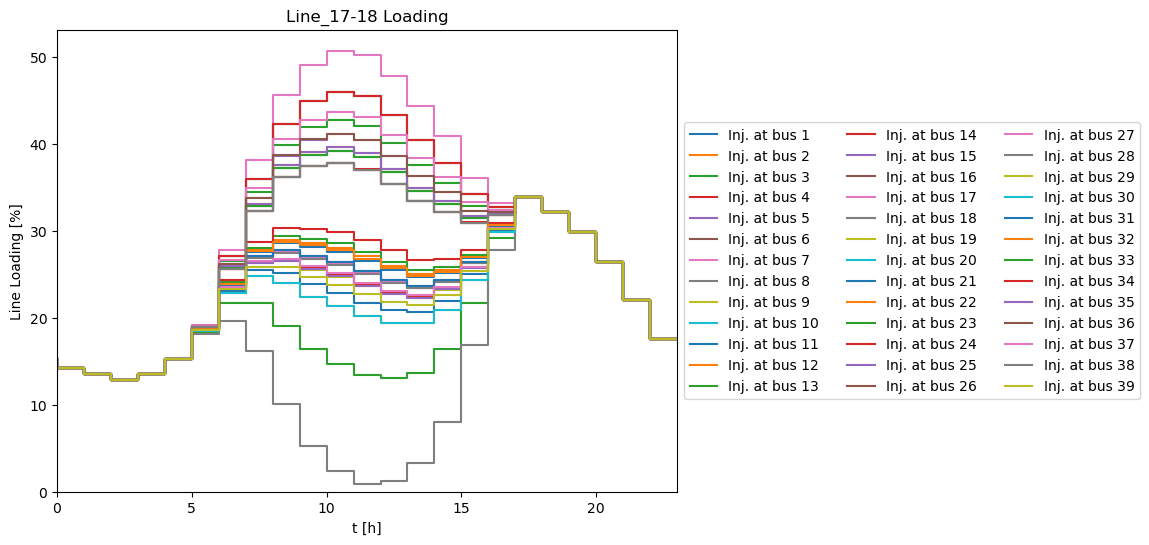

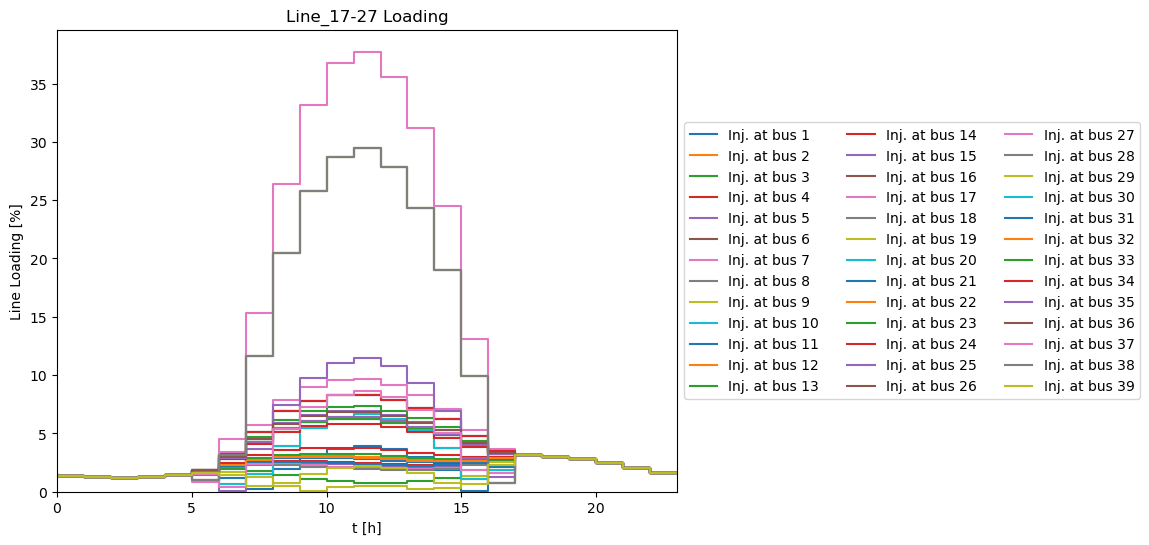

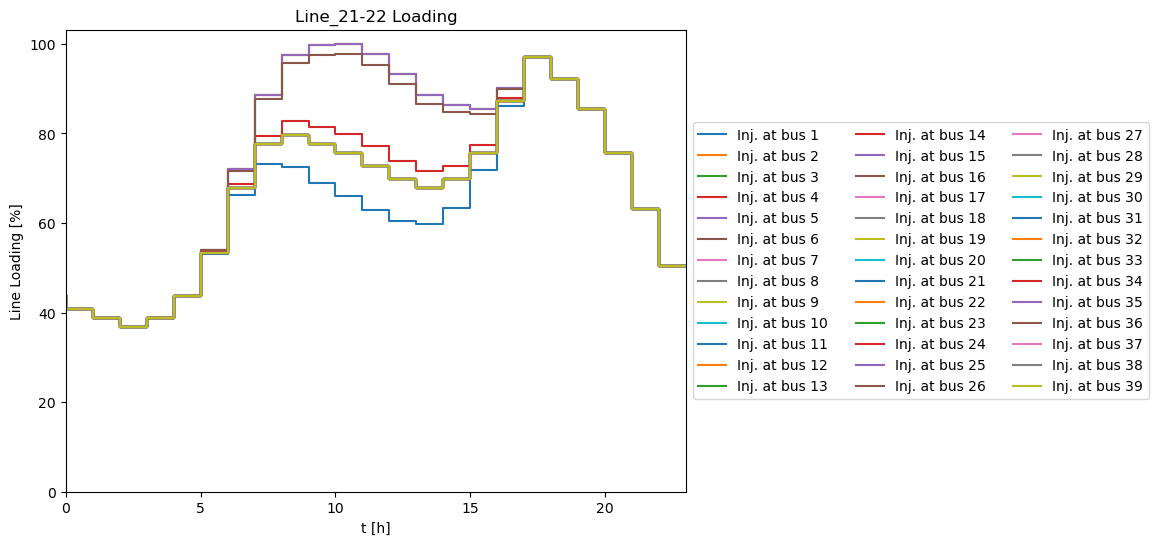

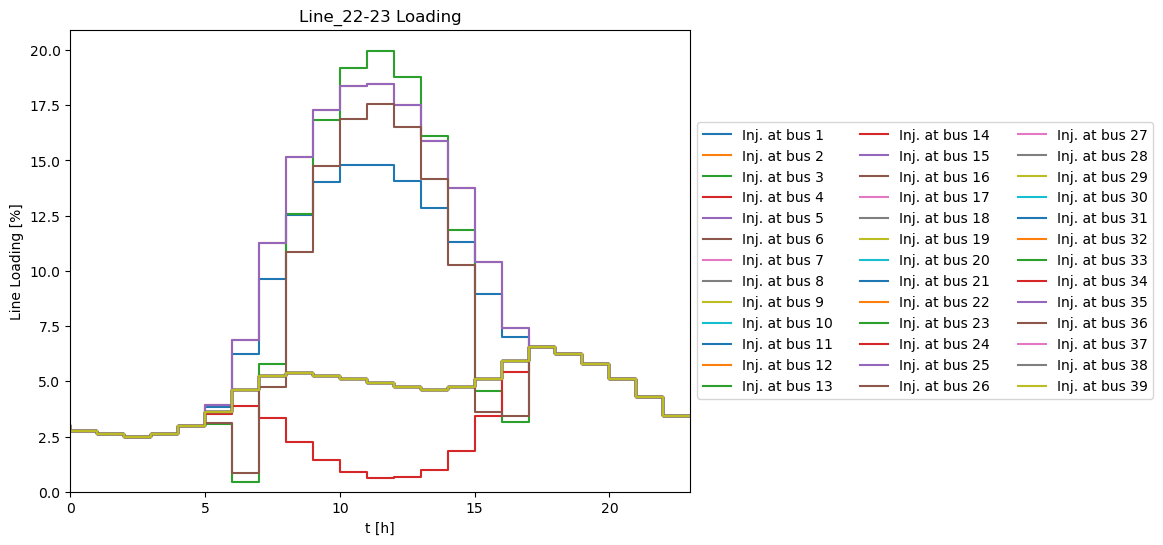

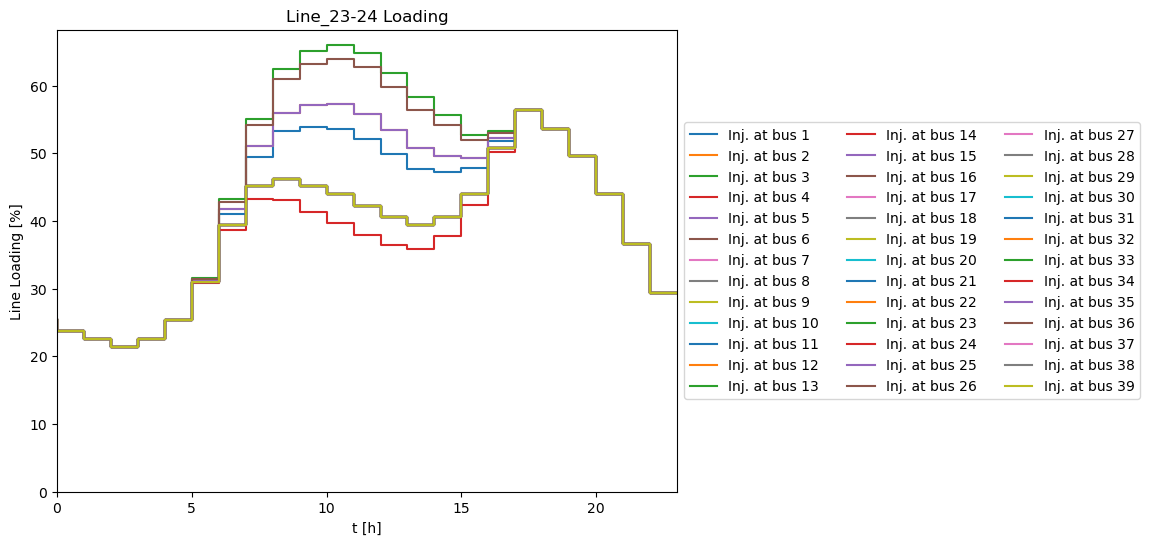

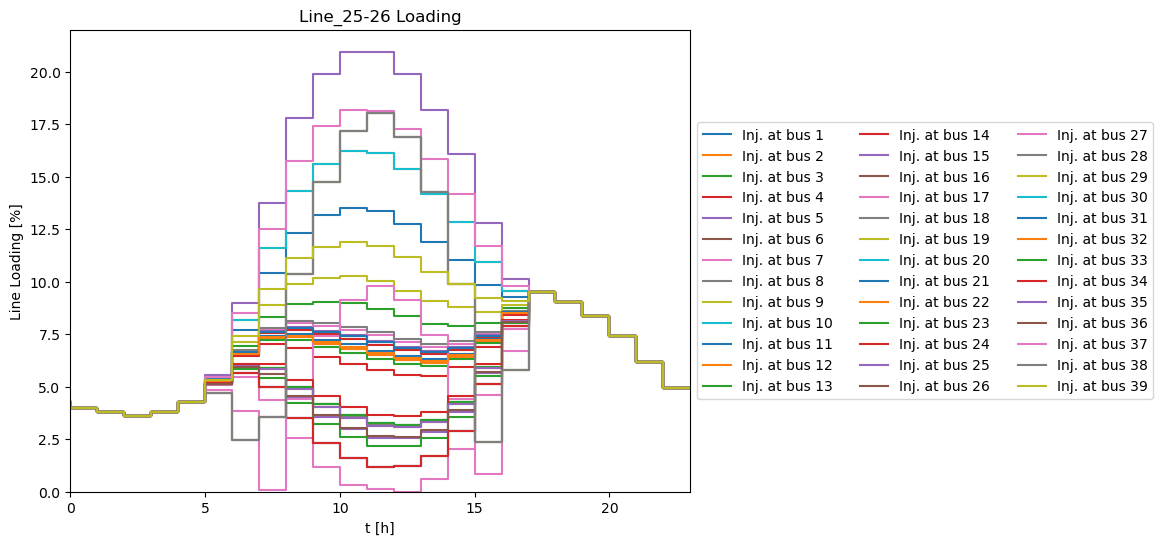

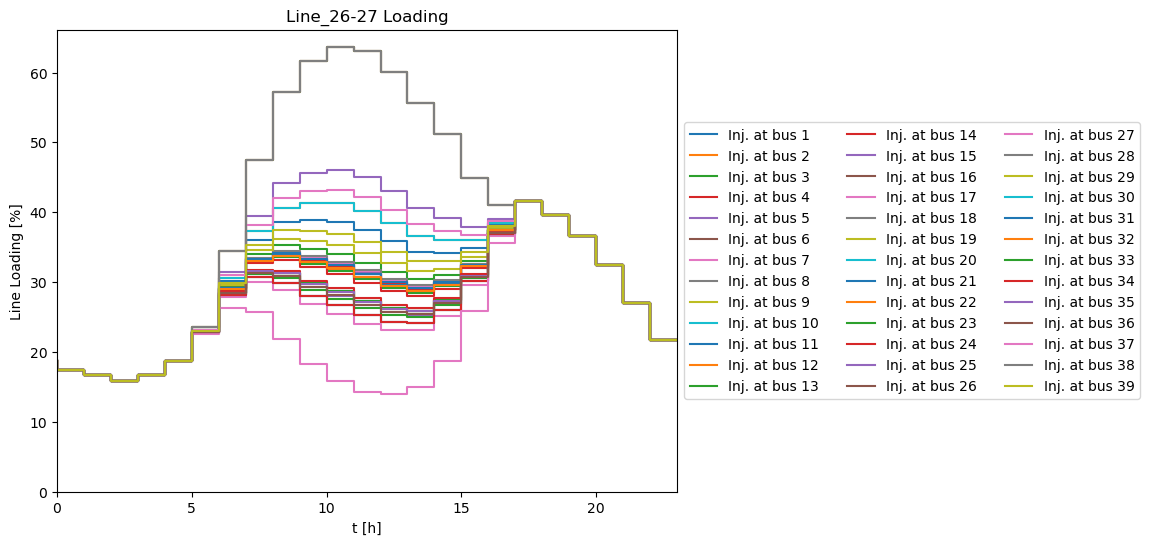

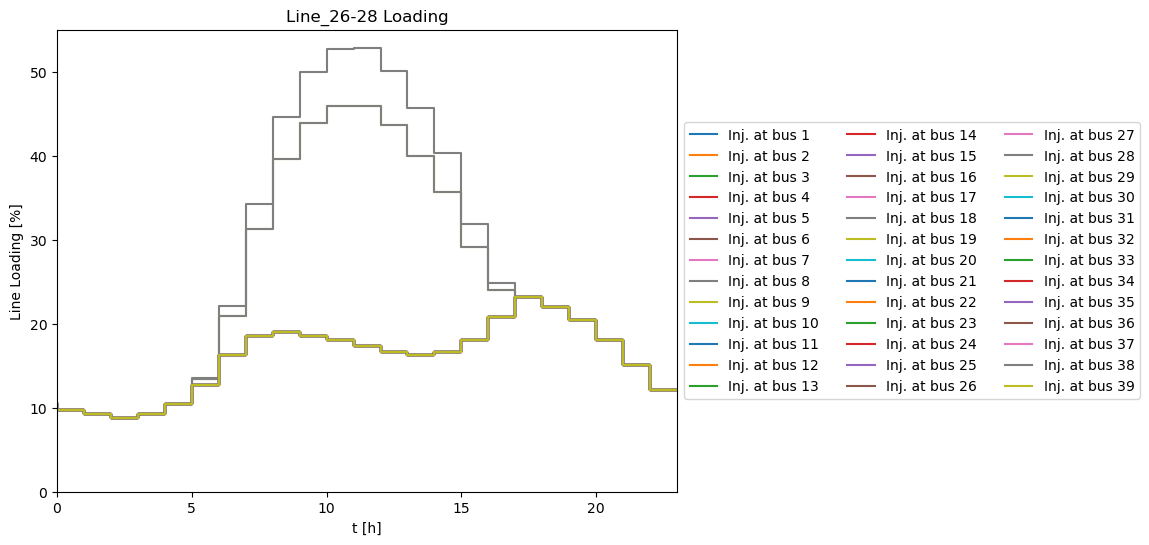

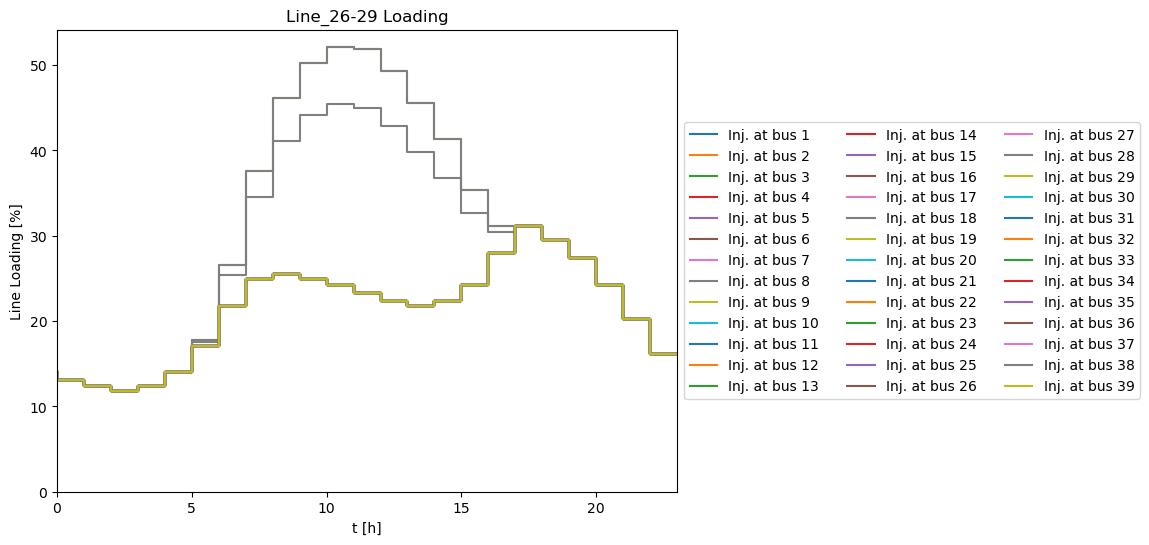

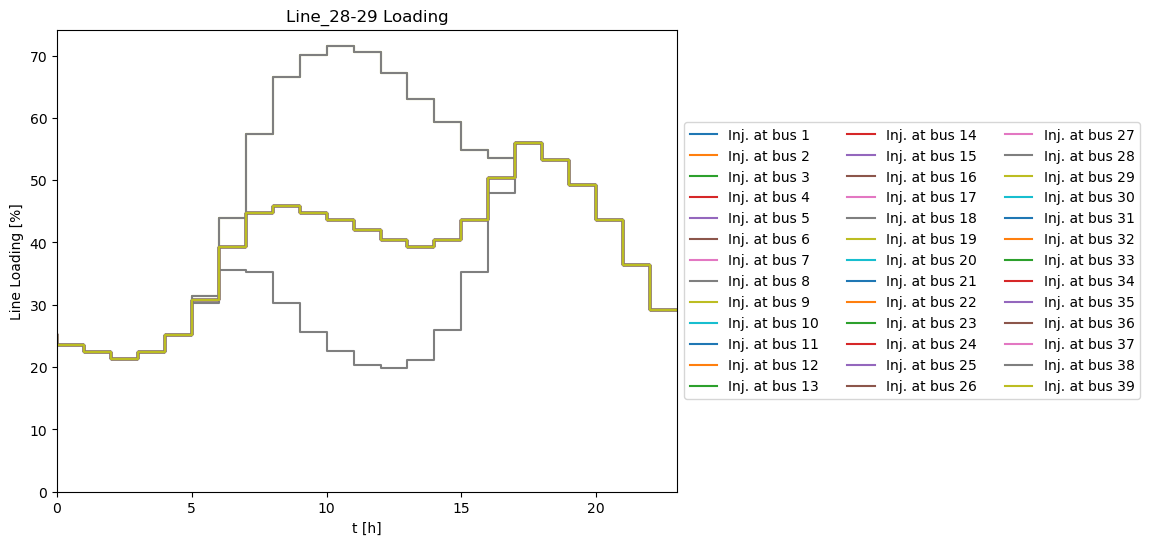

In [28]:
#-----------------------------------------------------------------------
    
#Plotting Line Loading for each bus injection of PV
    
#-----------------------------------------------------------------------

for i in range(len(sheet['lines'])):

    #extracting line parameters
    Pmax_ij = sheet['lines']['P_max_pu'][i]
    x_ij = sheet['lines']['x_pu'][i]
    fr_i = sheet['lines']['from_bus'][i]
    to_j = sheet['lines']['to_bus'][i]
    
    #initialize for generating set of legends
    lgnd = []
    t = np.array([0,1,2,3,4,5,
                 6,7,8,9,10,11,
                 12,13,14,15,16,17,
                 18,19,20,21,22,23])
    
    plt.figure(figsize=(8,6))
    
    for bus in range(n_bus):
        lineLoad = []
        for ts in range(k):
            lineLoad = np.hstack((lineLoad, 100*abs(np.deg2rad(theta_k[bus][(fr_i-1)*k+ts]) - np.deg2rad(theta_k[bus][(to_j-1)*k+ts])) / (x_ij * Pmax_ij)))
            
        if bus != (sheet['gens']['bus'][0]-100):
            #plot step graph
            plt.step(t, lineLoad)
    
            #generate and concatenate legends
            if len(lgnd) == 0:
                lgnd = ["Inj. at bus " + str(bus+1)]
            else:
                lgnd = np.hstack((lgnd, ["Inj. at bus " + str(bus+1)]))
    
    #plot settings
    plt.xlabel("t [h]")
    plt.ylabel("Line Loading [%]")
    plt.title("Line_" + str(min(sheet['lines']['from_bus'][i],sheet['lines']['to_bus'][i])) + "-" + str(max(sheet['lines']['from_bus'][i],sheet['lines']['to_bus'][i])) + " Loading")
    plt.legend(lgnd,ncol=3,loc='center left', bbox_to_anchor=(1, 0.5))
    plt.ylim(bottom=0)
    plt.xlim(0,23)
    plt.show()

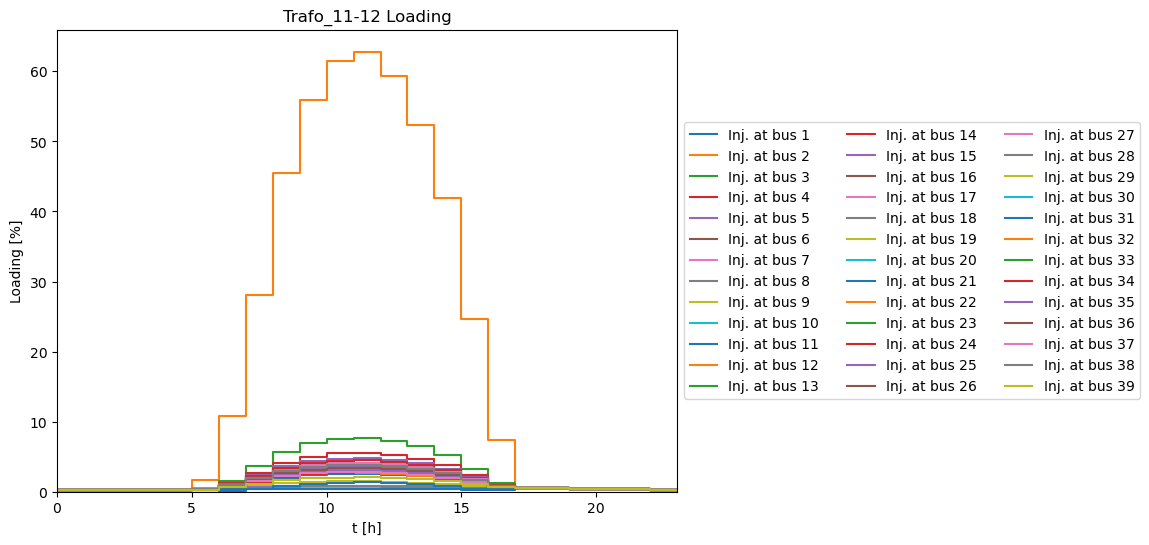

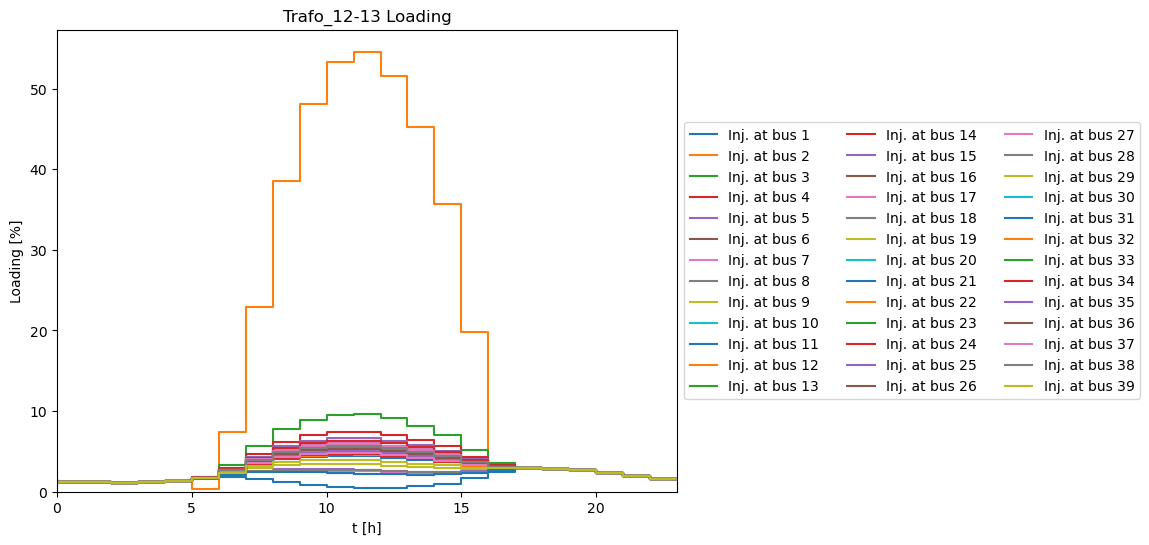

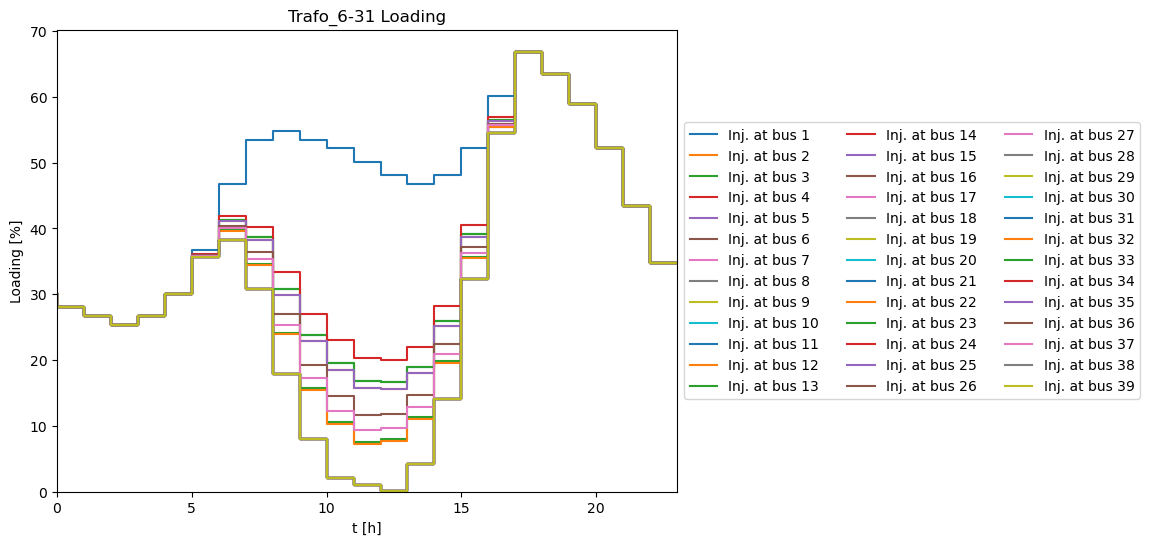

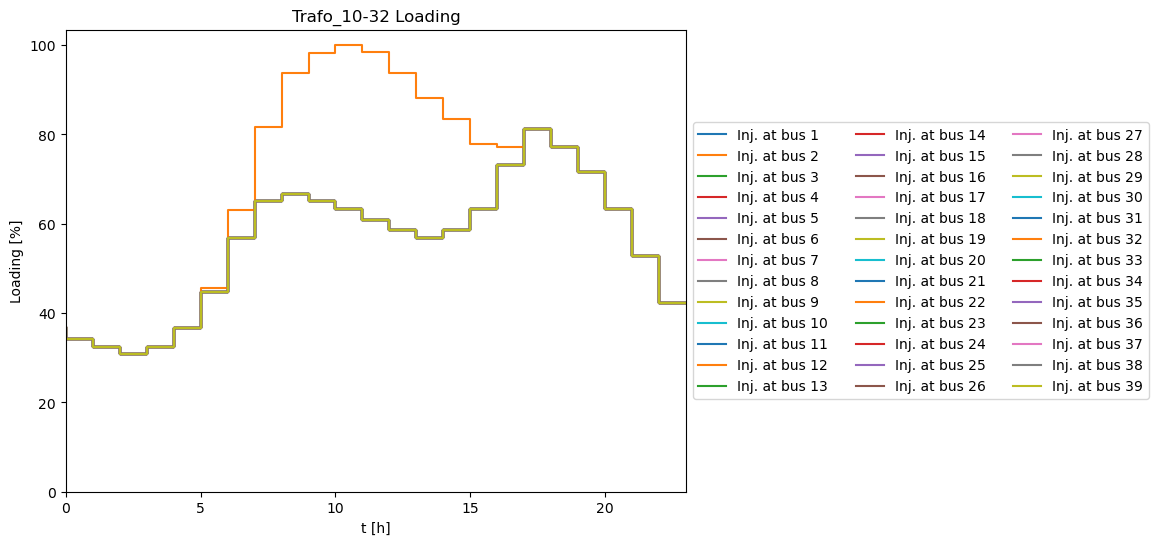

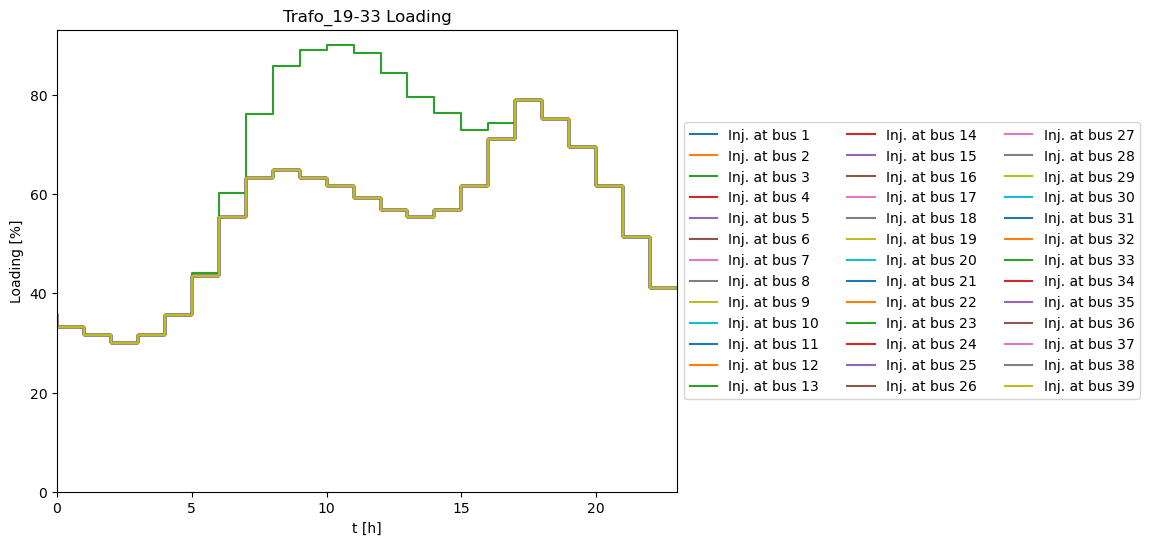

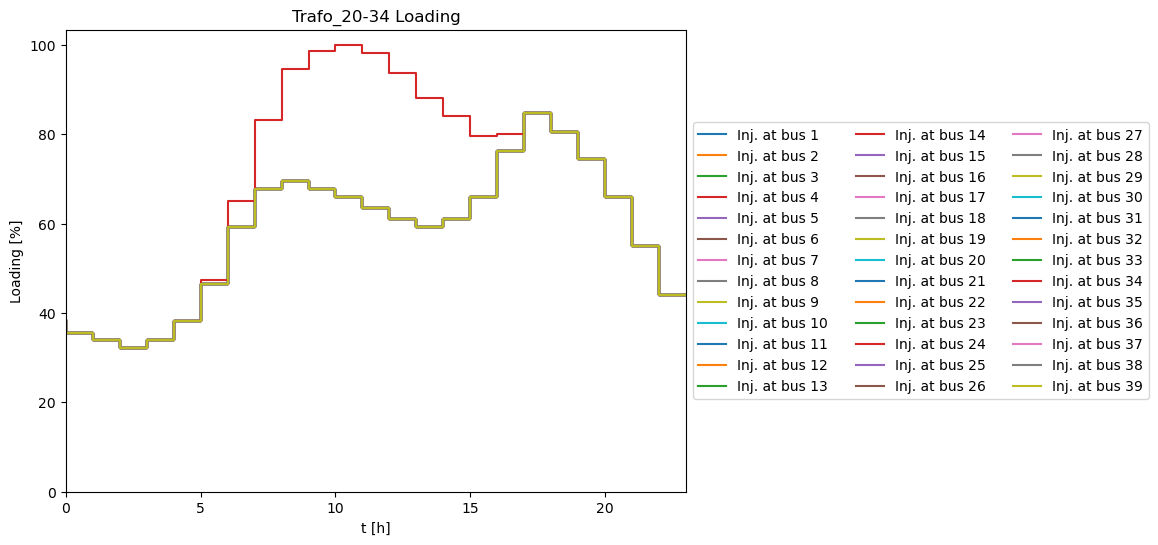

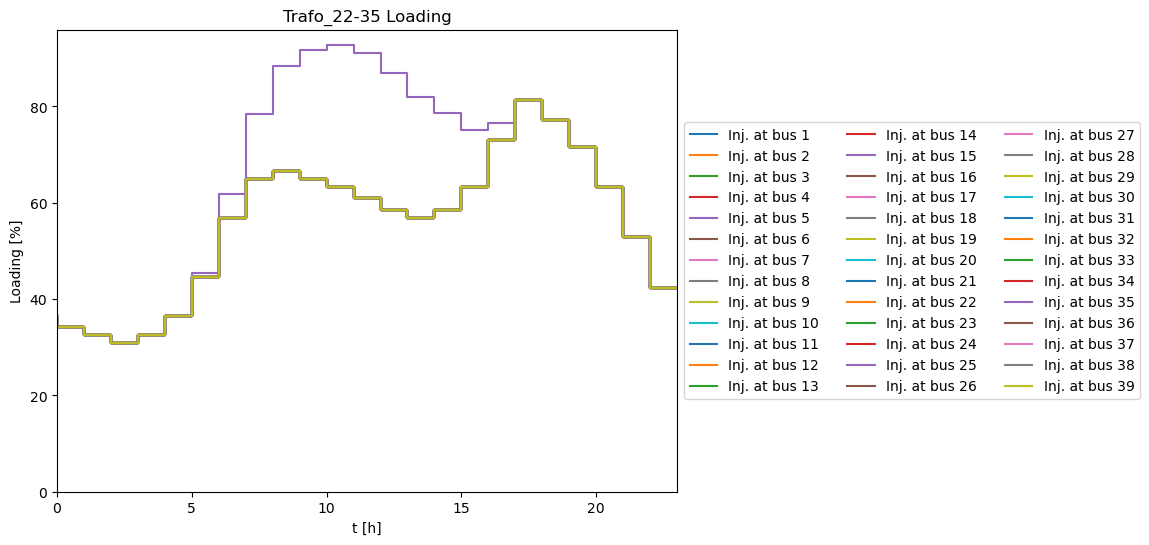

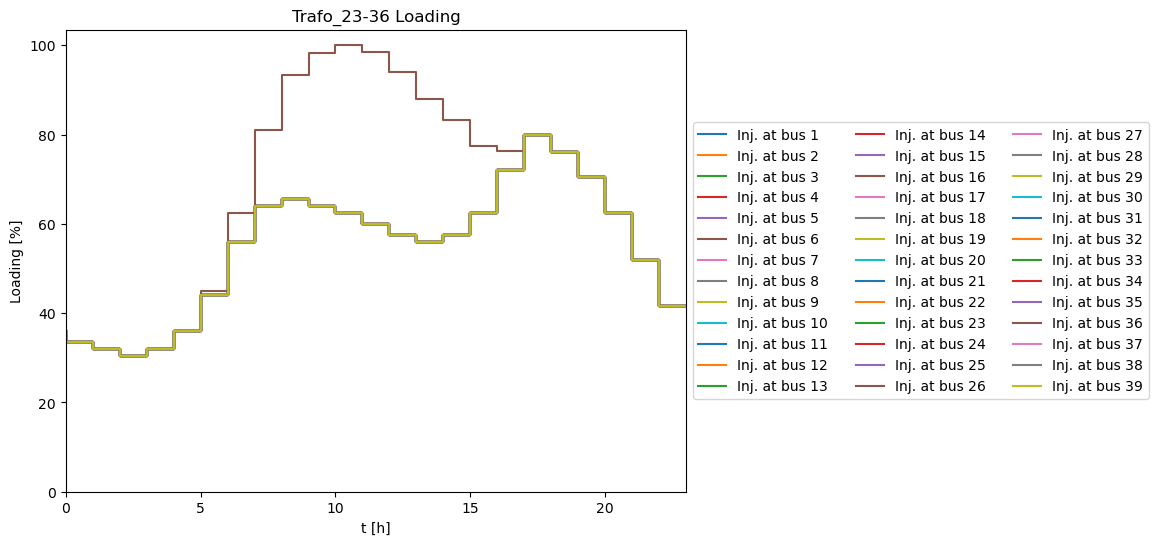

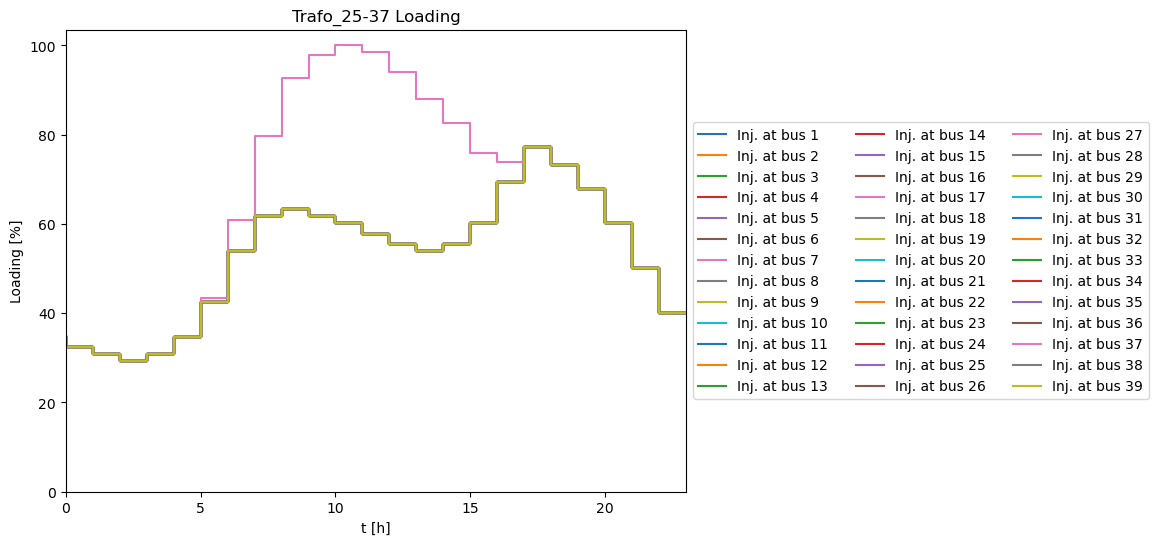

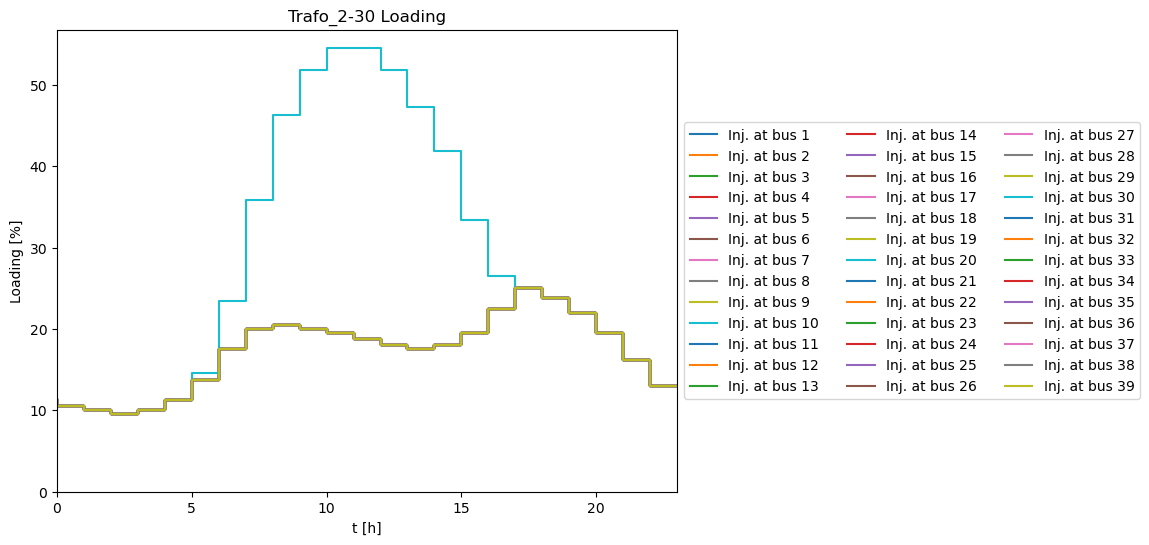

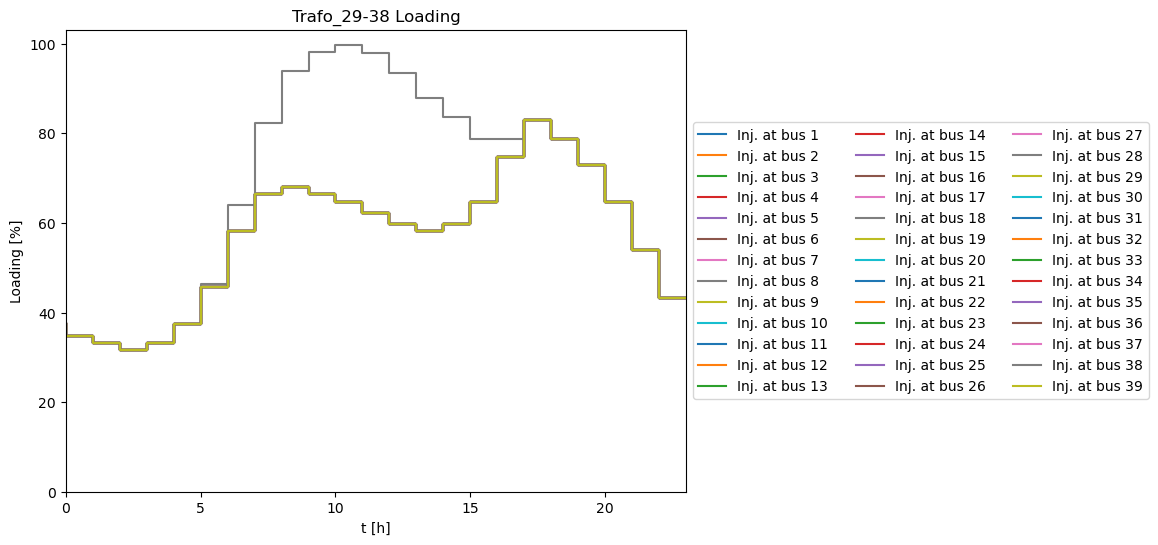

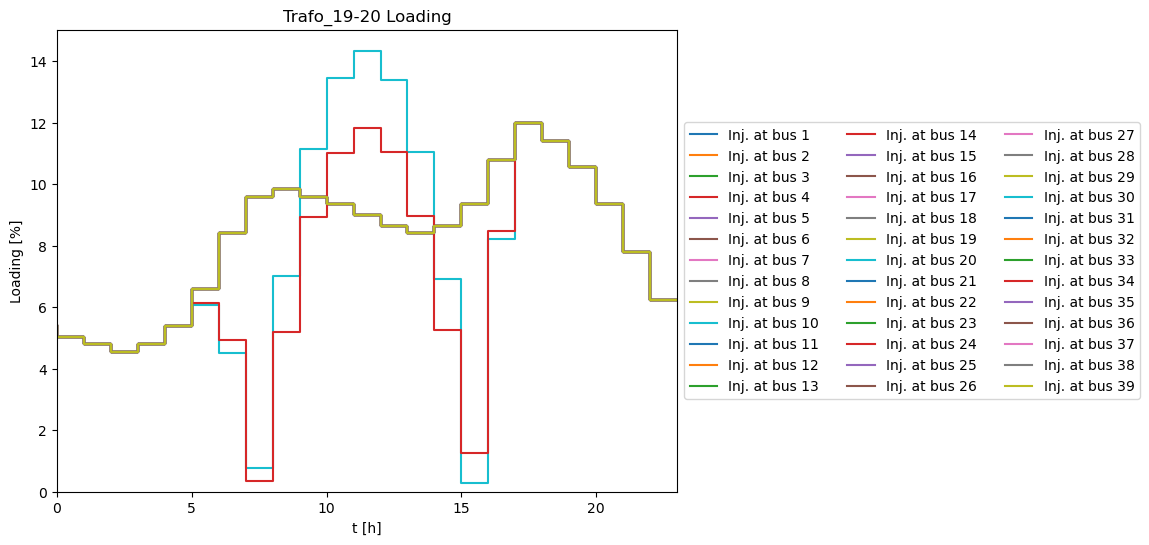

In [29]:
#-----------------------------------------------------------------------
    
#Plotting Transformer Loading for each bus injection of PV
    
#-----------------------------------------------------------------------

for i in range(len(sheet['trafos'])):

    #extracting line parameters
    Pmax_ij = sheet['trafos']['P_max_pu'][i]
    x_ij = sheet['trafos']['x_pu'][i]
    phi_ij = np.deg2rad(sheet['trafos']['shift_degree'][i])
    fr_i = sheet['trafos']['from_bus'][i]
    to_j = sheet['trafos']['to_bus'][i]
    
    #initialize for generating set of legends
    lgnd = []
    t = np.array([0,1,2,3,4,5,
                 6,7,8,9,10,11,
                 12,13,14,15,16,17,
                 18,19,20,21,22,23])
    
    plt.figure(figsize=(8,6))
    
    for bus in range(n_bus):
        trafoLoad = []
        for ts in range(k):
            trafoLoad = np.hstack((trafoLoad, 100*abs(np.deg2rad(theta_k[bus][(fr_i-1)*k+ts]) - np.deg2rad(theta_k[bus][(to_j-1)*k+ts]) + phi_ij) / (x_ij * Pmax_ij)))
            
        if bus != (sheet['gens']['bus'][0]-100):
            #plot step graph
            plt.step(t, trafoLoad)
    
            #generate and concatenate legends
            if len(lgnd) == 0:
                lgnd = ["Inj. at bus " + str(bus+1)]
            else:
                lgnd = np.hstack((lgnd, ["Inj. at bus " + str(bus+1)]))
    
    #plot settings
    plt.xlabel("t [h]")
    plt.ylabel("Loading [%]")
    plt.title("Trafo_" + str(min(sheet['trafos']['from_bus'][i],sheet['trafos']['to_bus'][i])) + "-" + str(max(sheet['trafos']['from_bus'][i],sheet['trafos']['to_bus'][i])) + " Loading")
    plt.legend(lgnd,ncol=3,loc='center left', bbox_to_anchor=(1, 0.5))
    plt.ylim(bottom=0)
    plt.xlim(0,23)
    plt.show()